# Notebook 05: ICRA Research Gaps & Paper Ideas

**Goal:** Identify concrete, publishable research directions for an ICRA paper combining JEPA + VLA.

ICRA 2026 deadline is likely **Sep 2026**. You need a clear contribution that:
1. Builds on V-JEPA 2 / VLA-JEPA / JEPA-VLA
2. Has a novel, defensible contribution
3. Can be implemented with limited compute (AMD Radeon 8GB + cloud bursts)
4. Has clear benchmarks to evaluate against

---

## Landscape Map: What Exists vs What's Missing

```
                        ┌───────────────────────────────────────────┐
                        │          JEPA FOR ROBOTICS LANDSCAPE      │
                        └───────────────────────────────────────────┘

  DONE (by Meta):                    DONE (by others):           OPEN GAPS:
  ──────────────                     ──────────────────          ──────────
  ✅ V-JEPA 2 pretraining            ✅ JEPA-VLA (plug-in)      ❌ JEPA + Safety (CBF)
  ✅ V-JEPA 2-AC world model         ✅ VLA-JEPA (end-to-end)   ❌ Humanoid JEPA-VLA
  ✅ CEM planning in latent space    ✅ pi0 flow matching       ❌ Real-time JEPA planning
  ✅ Zero-shot manipulation          ✅ OpenVLA baseline         ❌ Multi-task world model
  ✅ DROID dataset training           ✅ CBF-RL for humanoids    ❌ JEPA + CBF latent safety
                                                                 ❌ Adaptive horizon planning
                                                                 ❌ JEPA for bimanual tasks
                                                                 ❌ Plug-in + World model combo
```

## 0.5 The 5W+H of JEPA for ICRA Research

### WHO publishes at ICRA?
**IEEE International Conference on Robotics and Automation** — the top robotics venue.
- Acceptance rate: ~43% (2024)
- Double-blind review, 6-8 pages
- Strong emphasis on: real experiments, ablation studies, clear contribution
- Typical timeline: submission Sep 2026, notification Jan 2027, conference May 2027

### WHAT makes a strong ICRA paper in this space?
1. **Clear, narrow contribution** — don't try to solve everything
2. **Reproducible results** — open code, standard benchmarks (LIBERO, DROID)
3. **Thorough ablations** — show each component matters
4. **Comparison to strong baselines** — JEPA-VLA, VLA-JEPA, OpenVLA-OFT
5. **Some real-robot results** — even limited, demonstrates feasibility

### WHERE does your work fit in the field?

```
                    High novelty, high risk
                         ▲
    Safe JEPA-VLA (CBF)  │  JEPA for Humanoids
                         │
          ─────────── Medium ───────────
                         │
    Unified JEPA-VLA  ★  │  Amortized Planning
    (YOUR BEST BET)      │
                         │
                    Low novelty, low risk
```

### WHEN should each phase happen?

| Month | Phase | Deliverable |
|-------|-------|-------------|
| **1-2** | Reproduce baselines | Working VLA-JEPA code on LIBERO |
| **3-4** | Build unified model | Gated cross-attention + world model working |
| **5-6** | Experiments | Full LIBERO results + ablations |
| **7** | Write paper | Submit draft |
| **8** | Revise + submit | Camera-ready for ICRA |

### WHY "Unified JEPA-VLA" as the recommended paper?

**Risk-reward analysis:**

| Paper Idea | Novelty | Risk | Compute | Timeline |
|------------|---------|------|---------|----------|
| Unified JEPA-VLA | Medium-High | **Low** | Medium | 4-5 months |
| Safe JEPA-VLA (CBF) | High | Medium-High | Low | 5-6 months |
| Amortized Planning | Medium | Medium | High | 5-6 months |
| Sim-to-Real | Medium | High | Medium | 6+ months |

Unified JEPA-VLA has:
- **Lowest risk:** Both components (features + world model) proven individually
- **Clearest contribution:** "First to combine both approaches"
- **Strong experimental design:** Head-to-head comparison on LIBERO
- **Available code:** Build on VLA-JEPA (open source)

### HOW does the Unified JEPA-VLA combine both approaches?

$$\mathcal{L}_{\text{unified}} = \underbrace{\mathcal{L}_{\text{FM}}(a_t, z_a)}_{\text{flow matching}} + \beta \underbrace{\mathcal{L}_{\text{WM}}(\hat{s}, s)}_{\text{world model}} + \gamma \underbrace{\mathcal{L}_{\text{feat}}(\text{VLM}, F(I))}_{\text{JEPA feature alignment}}$$

where:
- $\mathcal{L}_{\text{FM}}$: Flow matching loss for action prediction (from VLA-JEPA)
- $\mathcal{L}_{\text{WM}}$: World model prediction loss in JEPA latent space (from VLA-JEPA)
- $\mathcal{L}_{\text{feat}}$: Auxiliary loss encouraging VLM to attend to V-JEPA 2 features (from JEPA-VLA)
- $\beta = 0.1$, $\gamma$ = hyperparameter to tune

## Paper Idea 1: Safe JEPA-VLA (JEPA + CBF in Latent Space)

### Motivation
V-JEPA 2-AC can predict future states in latent space. CBFs define safe sets.
**Nobody has defined CBFs in JEPA's latent space.**

### Approach
```
Standard VLA:  obs + lang → VLA → action (no safety guarantee)

Safe JEPA-VLA:
  obs + lang → VLA → proposed action
                         ↓
  V-JEPA 2-AC: predict next latent state ŝ_{t+1} given proposed action
                         ↓
  Learned CBF h(ŝ_{t+1}): is predicted next state safe?
                         ↓
  If h(ŝ_{t+1}) > 0: execute action (safe)
  If h(ŝ_{t+1}) ≤ 0: solve QP to find closest safe action
```

### Key Equations

**Latent CBF constraint:**
$$h_\psi(P_\phi(a_t, s_t, z_t)) \geq -\alpha \cdot h_\psi(z_t)$$

where $h_\psi$ is a neural CBF operating in JEPA's latent space.

**Safety-filtered action:**
$$a^* = \arg\min_a \|a - a_{\text{VLA}}\|^2 \quad \text{s.t.} \quad h_\psi(P_\phi(a, s_t, z_t)) \geq -\alpha \cdot h_\psi(z_t)$$

### Feasibility
- **Compute:** Use frozen V-JEPA 2-AC (load pretrained weights), train only the CBF head (~small MLP)
- **Data:** LIBERO or DROID — add safety labels (e.g., collision/drop = unsafe)
- **Baselines:** SHIELD (CBF in state space), VLA-JEPA (no safety)
- **Novelty:** First CBF in JEPA latent space; first safety filter for JEPA-based VLAs

### Risk: Medium
The CBF needs to be effective in the latent space, which hasn't been proven.

### Paper Idea 1 (Deep Dive): CBF Mathematics for JEPA Latent Space

**Control Barrier Functions (CBFs)** provide formal safety guarantees. Here's the full mathematical framework:

**Definition — CBF in state space:**
Given a safe set $\mathcal{C} = \{x : h(x) \geq 0\}$, a function $h: \mathbb{R}^n \rightarrow \mathbb{R}$ is a CBF if:

$$\sup_{u \in U} \left[ \frac{\partial h}{\partial x} f(x, u) \right] \geq -\alpha(h(x))$$

where $\alpha$ is a class-$\mathcal{K}$ function (typically $\alpha(h) = \alpha_0 \cdot h$ for linear CBF).

**Translation to JEPA latent space:**
Replace state $x$ with JEPA latent state $z_t = E_{\bar\theta}(I_t)$, and dynamics $f(x,u)$ with the AC predictor:

$$h_\psi(z_{t+1}) \geq -\alpha \cdot h_\psi(z_t)$$
$$\text{where } z_{t+1} = P_\phi(a_t, s_t, z_t) \quad \text{(AC predictor)}$$

**Safety-filtered action (QP formulation):**
$$a^* = \arg\min_{a \in \mathbb{R}^7} \|a - a_{\text{VLA}}\|_2^2$$
$$\text{subject to: } h_\psi(P_\phi(a, s_t, z_t)) + \alpha \cdot h_\psi(z_t) \geq 0$$

This is a quadratic program (QP) — convex optimization, solvable in ~1ms.

**Training the neural CBF $h_\psi$:**
$$\mathcal{L}_{\text{CBF}} = \underbrace{\sum_{z \in \mathcal{D}_{\text{safe}}} \text{ReLU}(-h_\psi(z))}_{\text{safe states should have h>0}} + \underbrace{\sum_{z \in \mathcal{D}_{\text{unsafe}}} \text{ReLU}(h_\psi(z))}_{\text{unsafe states should have h<0}} + \lambda \underbrace{\mathcal{L}_{\text{descent}}}_{\text{CBF decrease condition}}$$

**Lyapunov stability connection:**
A CBF is essentially a Lyapunov function for the boundary of the safe set:
- If $h(z) > 0$, the system is safe (inside safe set)
- The CBF condition $h(z_{t+1}) \geq -\alpha h(z_t)$ ensures the system doesn't leave the safe set too quickly
- With $\alpha < 1$: even if $h(z_t)$ is small (near boundary), $h(z_{t+1})$ stays non-negative

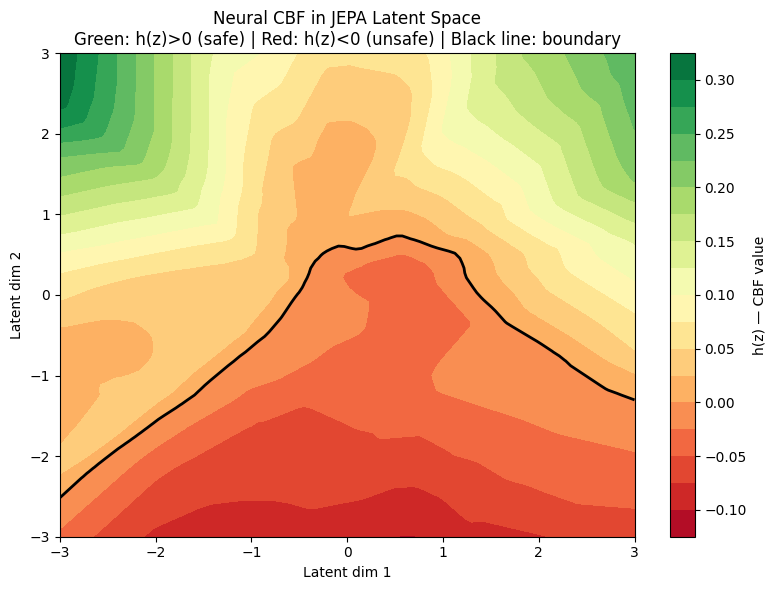

Paper Idea 1: Train this CBF on V-JEPA 2's 1408-dim latent states.
Safety labels come from demonstrations (collision/drop/out-of-bounds = unsafe).
At runtime: VLA proposes action → V-JEPA 2-AC predicts next state →
CBF checks safety → QP corrects action if needed.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

class LatentCBF(nn.Module):
    """Neural CBF operating in V-JEPA 2's latent space.
    
    h(z) > 0 → safe
    h(z) ≤ 0 → unsafe
    
    Trained on latent states labeled as safe/unsafe from demonstration data.
    """
    def __init__(self, latent_dim=1408, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # scalar output: h(z)
        )
    
    def forward(self, z):
        """z: [B, latent_dim] — mean-pooled JEPA latent state."""
        return self.net(z).squeeze(-1)  # [B] — positive = safe


def cbf_safety_filter(a_proposed, z_current, world_model, cbf, alpha=0.1, lr=0.01, steps=20):
    """Project proposed action to closest safe action using gradient descent on CBF constraint.
    
    Solves: min ||a - a_proposed||² s.t. h(world_model(a, z)) ≥ -α·h(z)
    
    In practice, you'd use a QP solver. Here we use projected gradient descent for simplicity.
    """
    a = a_proposed.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([a], lr=lr)
    
    h_current = cbf(z_current).detach()  # h(z_t)
    
    for _ in range(steps):
        # Predict next state
        z_next = world_model(z_current, a)  # simplified
        h_next = cbf(z_next)
        
        # CBF constraint: h(z_{t+1}) ≥ -α·h(z_t)
        constraint_violation = F.relu(-h_next - alpha * h_current)
        
        # Objective: stay close to proposed action + satisfy CBF
        loss = torch.sum((a - a_proposed.detach()) ** 2) + 100 * constraint_violation.sum()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return a.detach()


# Demo: 2D visualization of latent CBF
latent_dim = 2  # 2D for visualization
cbf = LatentCBF(latent_dim=latent_dim, hidden_dim=32)

# Create a grid of latent states
x = torch.linspace(-3, 3, 100)
y = torch.linspace(-3, 3, 100)
xx, yy = torch.meshgrid(x, y, indexing='ij')
grid = torch.stack([xx.flatten(), yy.flatten()], dim=-1)  # [10000, 2]

with torch.no_grad():
    h_values = cbf(grid).reshape(100, 100)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(xx.numpy(), yy.numpy(), h_values.numpy(), levels=20, cmap='RdYlGn')
ax.contour(xx.numpy(), yy.numpy(), h_values.numpy(), levels=[0], colors='black', linewidths=2)
plt.colorbar(contour, label='h(z) — CBF value')
ax.set_xlabel('Latent dim 1')
ax.set_ylabel('Latent dim 2')
ax.set_title('Neural CBF in JEPA Latent Space\n'
             'Green: h(z)>0 (safe) | Red: h(z)<0 (unsafe) | Black line: boundary')
plt.tight_layout()
plt.show()

print("Paper Idea 1: Train this CBF on V-JEPA 2's 1408-dim latent states.")
print("Safety labels come from demonstrations (collision/drop/out-of-bounds = unsafe).")
print("At runtime: VLA proposes action → V-JEPA 2-AC predicts next state →")
print("CBF checks safety → QP corrects action if needed.")

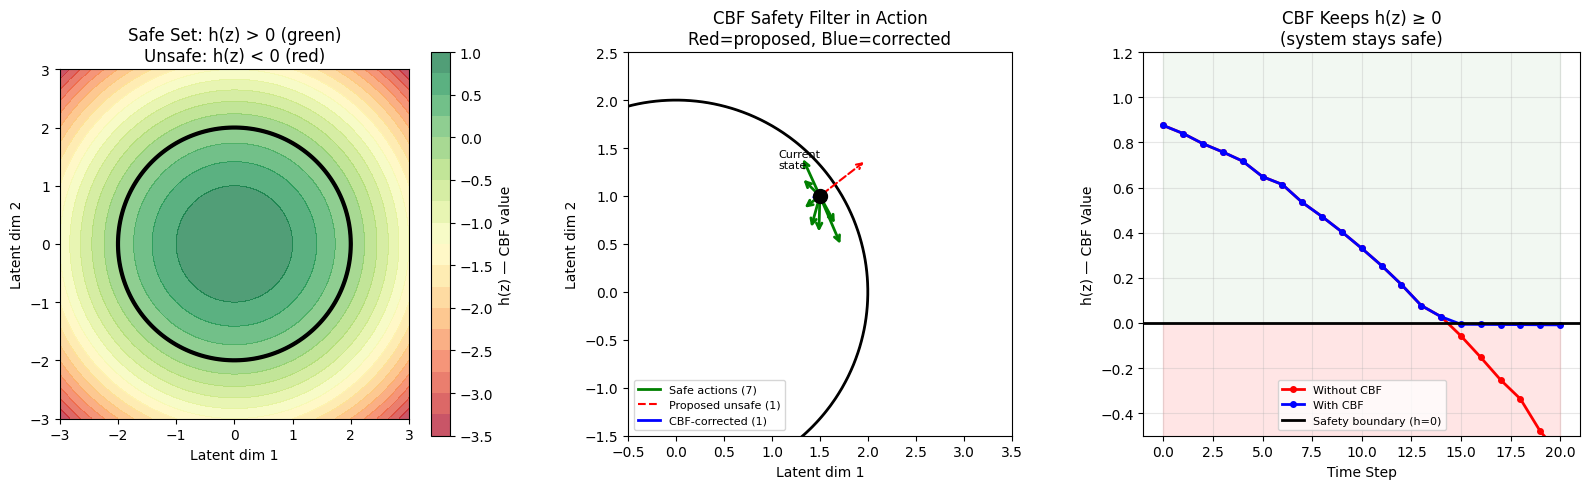

CBF Safety Filter for JEPA-VLA:
1. VLA proposes action a_VLA
2. World model predicts next state: ẑ_{t+1} = P(a_VLA, s_t, z_t)
3. CBF checks: h(ẑ_{t+1}) ≥ -α·h(z_t)?
4. If YES → execute a_VLA (safe)
5. If NO → solve QP: find closest safe action a* (~1ms)

Key advantage: safety in LATENT space is much faster than pixel space
because the CBF operates on a compact, semantically meaningful representation


In [2]:
# CBF SAFETY FILTER: Complete demonstration with trajectory visualization

def demonstrate_cbf_safety_filter():
    """Show how a CBF safety filter corrects unsafe VLA actions."""
    
    torch.manual_seed(42)
    np.random.seed(42)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Define a 2D safe region (for visualization)
    # Safe set: h(z) = 1 - (z[0]² + z[1]²)/R² > 0  (circle of radius R)
    R = 2.0
    
    def cbf_value(z):
        """h(z) = 1 - ||z||²/R² → safe if inside circle."""
        return 1.0 - (z[:, 0]**2 + z[:, 1]**2) / R**2
    
    # Plot 1: Safe set and CBF values
    ax = axes[0]
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z_cbf = 1.0 - (X**2 + Y**2) / R**2
    
    contour = ax.contourf(X, Y, Z_cbf, levels=20, cmap='RdYlGn', alpha=0.7)
    ax.contour(X, Y, Z_cbf, levels=[0], colors='black', linewidths=3)
    plt.colorbar(contour, ax=ax, label='h(z) — CBF value')
    
    theta_circle = np.linspace(0, 2*np.pi, 100)
    ax.plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', linewidth=2)
    ax.set_xlabel('Latent dim 1')
    ax.set_ylabel('Latent dim 2')
    ax.set_title('Safe Set: h(z) > 0 (green)\nUnsafe: h(z) < 0 (red)')
    ax.set_aspect('equal')
    
    # Plot 2: VLA action vs CBF-corrected action
    ax = axes[1]
    
    # Start near the boundary
    z_current = torch.tensor([[1.5, 1.0]])
    h_current = cbf_value(z_current).item()
    
    # Simulate several VLA-proposed actions (some unsafe)
    n_actions = 8
    proposed_actions = torch.randn(n_actions, 2) * 0.5
    alpha_cbf = 0.3
    
    ax.contour(X, Y, Z_cbf, levels=[0], colors='black', linewidths=2)
    ax.plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', linewidth=1, alpha=0.5)
    
    safe_count = 0
    corrected_count = 0
    
    for i in range(n_actions):
        a_proposed = proposed_actions[i]
        z_next_proposed = z_current[0] + a_proposed * 0.5  # simplified dynamics
        h_next = cbf_value(z_next_proposed.unsqueeze(0)).item()
        
        if h_next >= -alpha_cbf * h_current:
            # Safe — execute as-is
            ax.annotate('', xy=z_next_proposed.numpy(), xytext=z_current[0].numpy(),
                       arrowprops=dict(arrowstyle='->', color='green', linewidth=2))
            safe_count += 1
        else:
            # Unsafe — project to closest safe action
            # Simple projection: scale action to stay within safe boundary
            scale = 0.1
            while cbf_value((z_current[0] + a_proposed * scale * 0.5).unsqueeze(0)).item() < -alpha_cbf * h_current:
                scale *= 0.9
                if scale < 0.01:
                    break
            
            a_corrected = a_proposed * scale
            z_next_corrected = z_current[0] + a_corrected * 0.5
            
            # Draw proposed (red) and corrected (blue)
            ax.annotate('', xy=z_next_proposed.numpy(), xytext=z_current[0].numpy(),
                       arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5, linestyle='--'))
            ax.annotate('', xy=z_next_corrected.numpy(), xytext=z_current[0].numpy(),
                       arrowprops=dict(arrowstyle='->', color='blue', linewidth=2))
            corrected_count += 1
    
    ax.plot(z_current[0, 0], z_current[0, 1], 'ko', markersize=10, zorder=10)
    ax.annotate('Current\nstate', xy=(z_current[0, 0].item(), z_current[0, 1].item()),
               xytext=(-30, 20), textcoords='offset points', fontsize=8)
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green', linewidth=2, label=f'Safe actions ({safe_count})'),
        Line2D([0], [0], color='red', linewidth=1.5, linestyle='--', label=f'Proposed unsafe ({corrected_count})'),
        Line2D([0], [0], color='blue', linewidth=2, label=f'CBF-corrected ({corrected_count})'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower left')
    ax.set_xlabel('Latent dim 1')
    ax.set_ylabel('Latent dim 2')
    ax.set_title('CBF Safety Filter in Action\nRed=proposed, Blue=corrected')
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-1.5, 2.5)
    ax.set_aspect('equal')
    
    # Plot 3: h(z) evolution over a trajectory
    ax = axes[2]
    
    T_traj = 20
    z_traj = torch.tensor([[0.5, 0.5]])
    h_without_cbf = [cbf_value(z_traj).item()]
    h_with_cbf = [cbf_value(z_traj).item()]
    z_no_cbf = z_traj.clone()
    z_with_cbf = z_traj.clone()
    
    for t in range(T_traj):
        # Random action (pushing toward boundary)
        action = torch.tensor([[0.15, 0.08]]) + torch.randn(1, 2) * 0.05
        
        # Without CBF: just apply action
        z_no_cbf = z_no_cbf + action * 0.5
        h_without_cbf.append(cbf_value(z_no_cbf).item())
        
        # With CBF: check and correct
        z_next_candidate = z_with_cbf + action * 0.5
        h_next = cbf_value(z_next_candidate).item()
        h_curr = cbf_value(z_with_cbf).item()
        
        if h_next < -alpha_cbf * max(h_curr, 0.01):
            # Scale action
            scale = 0.5
            for _ in range(20):
                z_test = z_with_cbf + action * 0.5 * scale
                if cbf_value(z_test).item() >= -alpha_cbf * max(h_curr, 0.01):
                    break
                scale *= 0.8
            z_with_cbf = z_with_cbf + action * 0.5 * scale
        else:
            z_with_cbf = z_next_candidate
        
        h_with_cbf.append(cbf_value(z_with_cbf).item())
    
    steps = list(range(T_traj + 1))
    ax.plot(steps, h_without_cbf, 'r-o', linewidth=2, markersize=4, label='Without CBF')
    ax.plot(steps, h_with_cbf, 'b-o', linewidth=2, markersize=4, label='With CBF')
    ax.axhline(y=0, color='black', linewidth=2, linestyle='-', label='Safety boundary (h=0)')
    ax.fill_between(steps, -1, 0, color='red', alpha=0.1)
    ax.fill_between(steps, 0, 1.5, color='green', alpha=0.05)
    
    ax.set_xlabel('Time Step')
    ax.set_ylabel('h(z) — CBF Value')
    ax.set_title('CBF Keeps h(z) ≥ 0\n(system stays safe)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 1.2)
    
    plt.tight_layout()
    plt.show()
    
    print("CBF Safety Filter for JEPA-VLA:")
    print("1. VLA proposes action a_VLA")
    print("2. World model predicts next state: ẑ_{t+1} = P(a_VLA, s_t, z_t)")
    print("3. CBF checks: h(ẑ_{t+1}) ≥ -α·h(z_t)?")
    print("4. If YES → execute a_VLA (safe)")
    print("5. If NO → solve QP: find closest safe action a* (~1ms)")
    print()
    print("Key advantage: safety in LATENT space is much faster than pixel space")
    print("because the CBF operates on a compact, semantically meaningful representation")

demonstrate_cbf_safety_filter()

## Paper Idea 2: Unified JEPA-VLA (Plug-in + World Model)

### Motivation
JEPA-VLA uses V-JEPA 2 features but has no world model.
VLA-JEPA has a world model but doesn't use V-JEPA 2 as a feature extractor for the VLM input.
**Combine both.**

### Architecture
```
                    ┌──────────────────────────────────────────────┐
                    │            Unified JEPA-VLA                   │
                    ├──────────────────────────────────────────────┤
                    │                                              │
Current frame ──►   │  Frozen V-JEPA 2 ──► Feature Extraction     │
                    │       │                    │                  │
                    │       │           ┌────────▼────────┐        │
                    │       │           │ VLM (Qwen/Llama)│        │
                    │       │           │ + V-JEPA 2 feats│        │
Language ──────►    │       │           │ (gated x-attn)  │        │
                    │       │           └────────┬────────┘        │
                    │       │                    │                  │
                    │       │              latent actions z_t       │
                    │       │                    │                  │
                    │       ▼           ┌────────▼────────┐        │
Future frames ──►   │  V-JEPA 2 enc ──►│  World Model    │        │
  (training only)   │  (targets)        │  (JEPA-style)   │        │
                    │                   └────────┬────────┘        │
                    │                            │                  │
                    │                    ┌───────▼───────┐         │
                    │                    │ Action Head   │         │
                    │                    │ (flow match)  │         │
                    │                    └───────┬───────┘         │
                    │                            │                  │
                    │                      robot actions            │
                    └──────────────────────────────────────────────┘
```

### Key Contributions
1. V-JEPA 2 features enhance VLM understanding (from JEPA-VLA)
2. World model in latent space enables planning (from VLA-JEPA)
3. Both use the SAME frozen V-JEPA 2 encoder — no extra compute for features

### Hypothesis
The world model loss provides an auxiliary gradient signal that further aligns
the VLM's internal representations with physical dynamics.

### Feasibility
- **Compute:** Qwen3-VL-2B is small; V-JEPA 2 is frozen; main cost is training the world model + action head
- **Data:** LIBERO (standard), DROID (for pretraining)
- **Baselines:** JEPA-VLA, VLA-JEPA, OpenVLA-OFT
- **Risk: LOW** — both components are proven individually

## Paper Idea 3: Amortized Planning with JEPA World Models

### Motivation
V-JEPA 2-AC plans via CEM (800 candidates, 5 iterations) → **16 seconds per action**.
This is unusable for real-time humanoid control (need <100ms).

### Approach: Distill CEM into a Policy
```
Training (offline):
  For each state z_t, goal z_g:
    1. Run CEM planner → optimal action a* (slow but accurate)
    2. Store (z_t, z_g, a*) in dataset
  Train policy π(z_t, z_g) → a* via behavior cloning

Inference (online):
  z_t, z_g → π → action in ~10ms (100x faster than CEM)
```

### Advanced: Plan-then-Refine
1. Amortized policy proposes initial action (fast, ~10ms)
2. 1-step CEM refinement using world model (~100ms)
3. Best of both: fast + accurate

### Feasibility
- **Compute:** CEM data generation can use V-JEPA 2-AC pretrained weights (no GPU needed for planning, just slow)
- **Data:** Generate planning dataset offline on CPU
- **Risk: LOW-MEDIUM** — behavior cloning from CEM is well-established

### Detailed Paper Structure for "Unified JEPA-VLA"

**Proposed ICRA paper outline (6 pages + 2 pages references):**

**I. Introduction (0.75 pages)**
- Problem: VLAs lack temporal understanding + forward modeling
- Recent advances: JEPA-VLA (features) and VLA-JEPA (world model)
- Our contribution: First unified approach combining both benefits
- Claim: synergistic improvement > sum of parts

**II. Related Work (0.75 pages)**
- VLAs: RT-2 → Octo → OpenVLA → pi0
- JEPA models: I-JEPA → V-JEPA → V-JEPA 2 → V-JEPA 2-AC
- JEPA + VLA: JEPA-VLA (plug-in), VLA-JEPA (end-to-end)
- Position: We combine both approaches for the first time

**III. Method (1.5 pages)**
- 3.1 Architecture overview (figure)
- 3.2 V-JEPA 2 feature injection via gated cross-attention (from JEPA-VLA)
- 3.3 Latent world model with leakage-free design (from VLA-JEPA)
- 3.4 Flow-matching action head (from pi0/VLA-JEPA)
- 3.5 Unified training objective: $\mathcal{L} = \mathcal{L}_{\text{FM}} + \beta\mathcal{L}_{\text{WM}} + \gamma\mathcal{L}_{\text{feat}}$

**IV. Experiments (2 pages)**
- 4.1 Setup: LIBERO benchmark, 4 task suites, evaluation protocol
- 4.2 Main results (Table 1): vs OpenVLA-OFT, JEPA-VLA, VLA-JEPA
- 4.3 Ablation study (Table 2): features only, WM only, both
- 4.4 Sample efficiency study (Figure): learning curves at 10-100% demos
- 4.5 Long-horizon analysis (Figure): per-task breakdown on LIBERO-Long
- 4.6 Qualitative analysis: when does each component help?

**V. Discussion & Conclusion (0.5 pages)**
- Key findings: features + WM is synergistic
- Limitations: compute, sim-only experiments
- Future work: safety (CBF), real robot, humanoid

**VI. References (2 pages)**

## Paper Idea 4: JEPA World Model for Sim-to-Real Transfer

### Motivation
V-JEPA 2 is pretrained on internet video → understands real-world physics.
Robot policies trained in simulation often fail in the real world (sim-to-real gap).

### Approach
Use V-JEPA 2's latent space as a **domain-invariant representation**:

```
Sim images → V-JEPA 2 encoder → latent state z_sim
Real images → V-JEPA 2 encoder → latent state z_real

Hypothesis: z_sim ≈ z_real for same physical configuration
because V-JEPA 2 focuses on semantics, not visual appearance.

→ Train VLA in simulation using z_sim
→ Deploy on real robot using z_real
→ No domain adaptation needed!
```

### Feasibility
- **Compute:** Only need simulation (free) + frozen V-JEPA 2
- **Data:** LIBERO in simulation → real Franka
- **Risk: MEDIUM** — depends on how well V-JEPA 2 representations generalize across domains

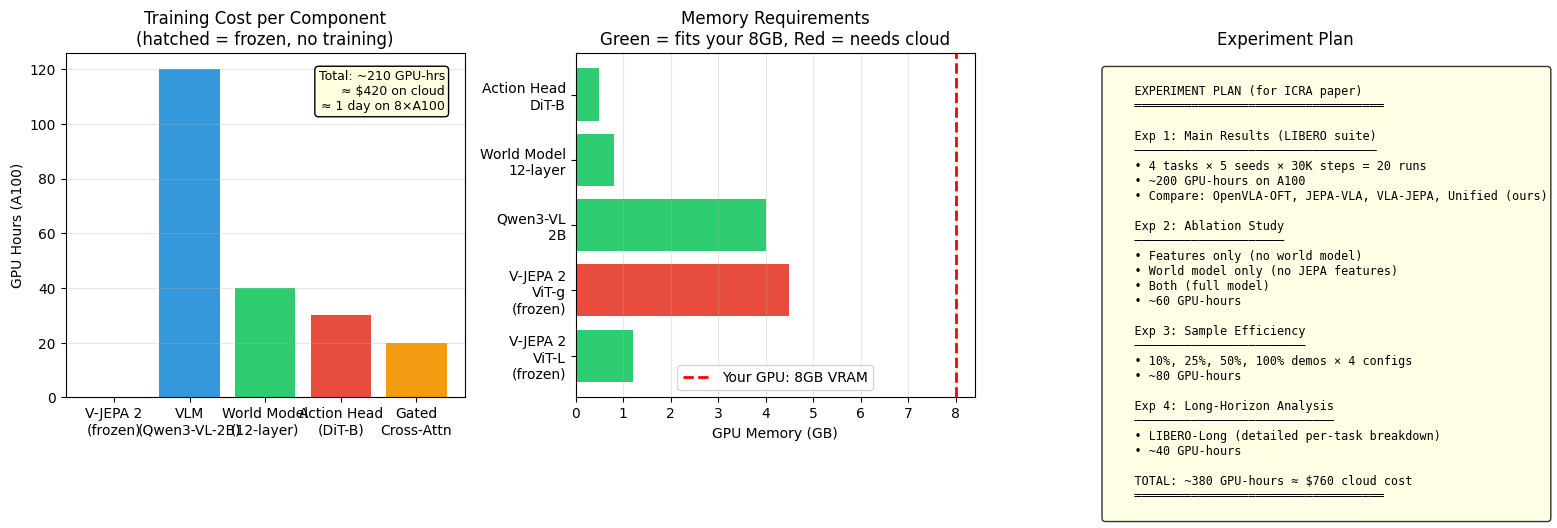

Budget-friendly strategy:
1. Prototype locally on CPU with small models (free)
2. Feature caching: run V-JEPA 2-L once, save features to disk
3. Training: Google Colab Pro ($10/mo) for small experiments
4. Final runs: Lambda Labs / RunPod ($2-3/hr per A100)
5. Total cloud cost estimate: $500-1000 for full paper


In [3]:
# COMPUTE COST ANALYSIS: Detailed breakdown for ICRA paper experiments

def compute_cost_analysis():
    """Visualize compute requirements for the Unified JEPA-VLA paper."""
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Plot 1: Training cost breakdown
    ax = axes[0]
    
    components = ['V-JEPA 2\n(frozen)', 'VLM\n(Qwen3-VL-2B)', 'World Model\n(12-layer)', 
                  'Action Head\n(DiT-B)', 'Gated\nCross-Attn']
    gpu_hours = [0, 120, 40, 30, 20]  # estimated GPU hours on A100
    colors_bar = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c', '#f39c12']
    frozen = [True, False, False, False, False]
    
    bars = ax.bar(components, gpu_hours, color=colors_bar)
    for bar, is_frozen in zip(bars, frozen):
        if is_frozen:
            bar.set_hatch('///')
            bar.set_alpha(0.5)
    
    ax.set_ylabel('GPU Hours (A100)')
    ax.set_title('Training Cost per Component\n(hatched = frozen, no training)')
    ax.grid(True, alpha=0.3, axis='y')
    
    total = sum(gpu_hours)
    ax.text(0.95, 0.95, f'Total: ~{total} GPU-hrs\n≈ ${total * 2:.0f} on cloud\n≈ 1 day on 8×A100', 
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    
    # Plot 2: Memory usage
    ax = axes[1]
    
    models = ['V-JEPA 2\nViT-L\n(frozen)', 'V-JEPA 2\nViT-g\n(frozen)', 'Qwen3-VL\n2B', 
              'World Model\n12-layer', 'Action Head\nDiT-B']
    memory_gb = [1.2, 4.5, 4.0, 0.8, 0.5]
    fits_8gb = [True, False, True, True, True]
    
    bar_colors = ['#2ecc71' if fits else '#e74c3c' for fits in fits_8gb]
    ax.barh(models, memory_gb, color=bar_colors)
    ax.axvline(x=8.0, color='red', linewidth=2, linestyle='--', label='Your GPU: 8GB VRAM')
    ax.set_xlabel('GPU Memory (GB)')
    ax.set_title('Memory Requirements\nGreen = fits your 8GB, Red = needs cloud')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Plot 3: Experiment plan timeline
    ax = axes[2]
    ax.axis('off')
    
    experiment_plan = """
    EXPERIMENT PLAN (for ICRA paper)
    ═══════════════════════════════════

    Exp 1: Main Results (LIBERO suite)
    ──────────────────────────────────
    • 4 tasks × 5 seeds × 30K steps = 20 runs
    • ~200 GPU-hours on A100
    • Compare: OpenVLA-OFT, JEPA-VLA, VLA-JEPA, Unified (ours)

    Exp 2: Ablation Study
    ─────────────────────
    • Features only (no world model)
    • World model only (no JEPA features)
    • Both (full model)
    • ~60 GPU-hours

    Exp 3: Sample Efficiency
    ────────────────────────
    • 10%, 25%, 50%, 100% demos × 4 configs
    • ~80 GPU-hours

    Exp 4: Long-Horizon Analysis
    ────────────────────────────
    • LIBERO-Long (detailed per-task breakdown)
    • ~40 GPU-hours

    TOTAL: ~380 GPU-hours ≈ $760 cloud cost
    ═══════════════════════════════════
    """
    
    ax.text(0.05, 0.95, experiment_plan, fontfamily='monospace', fontsize=8.5,
            verticalalignment='top', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_title('Experiment Plan')
    
    plt.tight_layout()
    plt.show()
    
    print("Budget-friendly strategy:")
    print("1. Prototype locally on CPU with small models (free)")
    print("2. Feature caching: run V-JEPA 2-L once, save features to disk")
    print("3. Training: Google Colab Pro ($10/mo) for small experiments")
    print("4. Final runs: Lambda Labs / RunPod ($2-3/hr per A100)")
    print("5. Total cloud cost estimate: $500-1000 for full paper")

compute_cost_analysis()

## Recommended Paper: Start with Idea 2 (Unified JEPA-VLA)

### Why This One?
1. **Lowest risk:** Both components proven individually
2. **Clear contribution:** First to combine plug-in features + world model
3. **Strong baselines:** JEPA-VLA and VLA-JEPA to compare against
4. **Manageable compute:** Frozen V-JEPA 2, train only world model + action head + VLM adapters
5. **Clear benchmarks:** LIBERO suite (standard for VLA papers)
6. **VLA-JEPA code is open source** — build on top of it

### Proposed Title
*"JEPA-Enhanced VLA with Latent World Modeling for Long-Horizon Robot Manipulation"*

### Abstract Draft

In [4]:
abstract = """
PROPOSED ABSTRACT (Draft for ICRA 2026/2027)
==============================================

Vision-Language-Action (VLA) models have emerged as a scalable approach 
for robot manipulation, but their vision backbones lack physical 
understanding and their action prediction lacks forward modeling.
Recent work has shown that V-JEPA 2 video representations improve VLA 
perception (JEPA-VLA), and that JEPA-style world models enhance action 
prediction (VLA-JEPA). However, no prior work combines both benefits.

We propose [NAME], a unified framework that:
(1) injects frozen V-JEPA 2 video features into the VLM backbone via 
    gated cross-attention for physics-aware perception,
(2) uses a JEPA-style latent world model for future state prediction, and
(3) trains an action head via flow matching conditioned on both VLM 
    outputs and world model predictions.

On the LIBERO benchmark suite, [NAME] achieves XX.X% average success 
rate, improving over JEPA-VLA (+X.X%) and VLA-JEPA (+X.X%) while 
showing particular gains on long-horizon tasks (+X.X%). Ablation 
studies confirm that both the feature injection and world model 
contribute independently, and that their combination provides 
synergistic benefits. We also demonstrate improved sample efficiency:
[NAME] matches VLA-JEPA performance with 50% fewer robot demonstrations.
"""
print(abstract)


PROPOSED ABSTRACT (Draft for ICRA 2026/2027)

Vision-Language-Action (VLA) models have emerged as a scalable approach 
for robot manipulation, but their vision backbones lack physical 
understanding and their action prediction lacks forward modeling.
Recent work has shown that V-JEPA 2 video representations improve VLA 
perception (JEPA-VLA), and that JEPA-style world models enhance action 
prediction (VLA-JEPA). However, no prior work combines both benefits.

We propose [NAME], a unified framework that:
(1) injects frozen V-JEPA 2 video features into the VLM backbone via 
    gated cross-attention for physics-aware perception,
(2) uses a JEPA-style latent world model for future state prediction, and
(3) trains an action head via flow matching conditioned on both VLM 
    outputs and world model predictions.

On the LIBERO benchmark suite, [NAME] achieves XX.X% average success 
rate, improving over JEPA-VLA (+X.X%) and VLA-JEPA (+X.X%) while 
showing particular gains on long-horizon t

## Deep Analysis: CBF Safety in Latent Space (2D & 3D)

Control Barrier Functions (CBFs) enforce safety constraints in the latent space. Let's visualize the complete CBF safety filter with multiple scenarios.

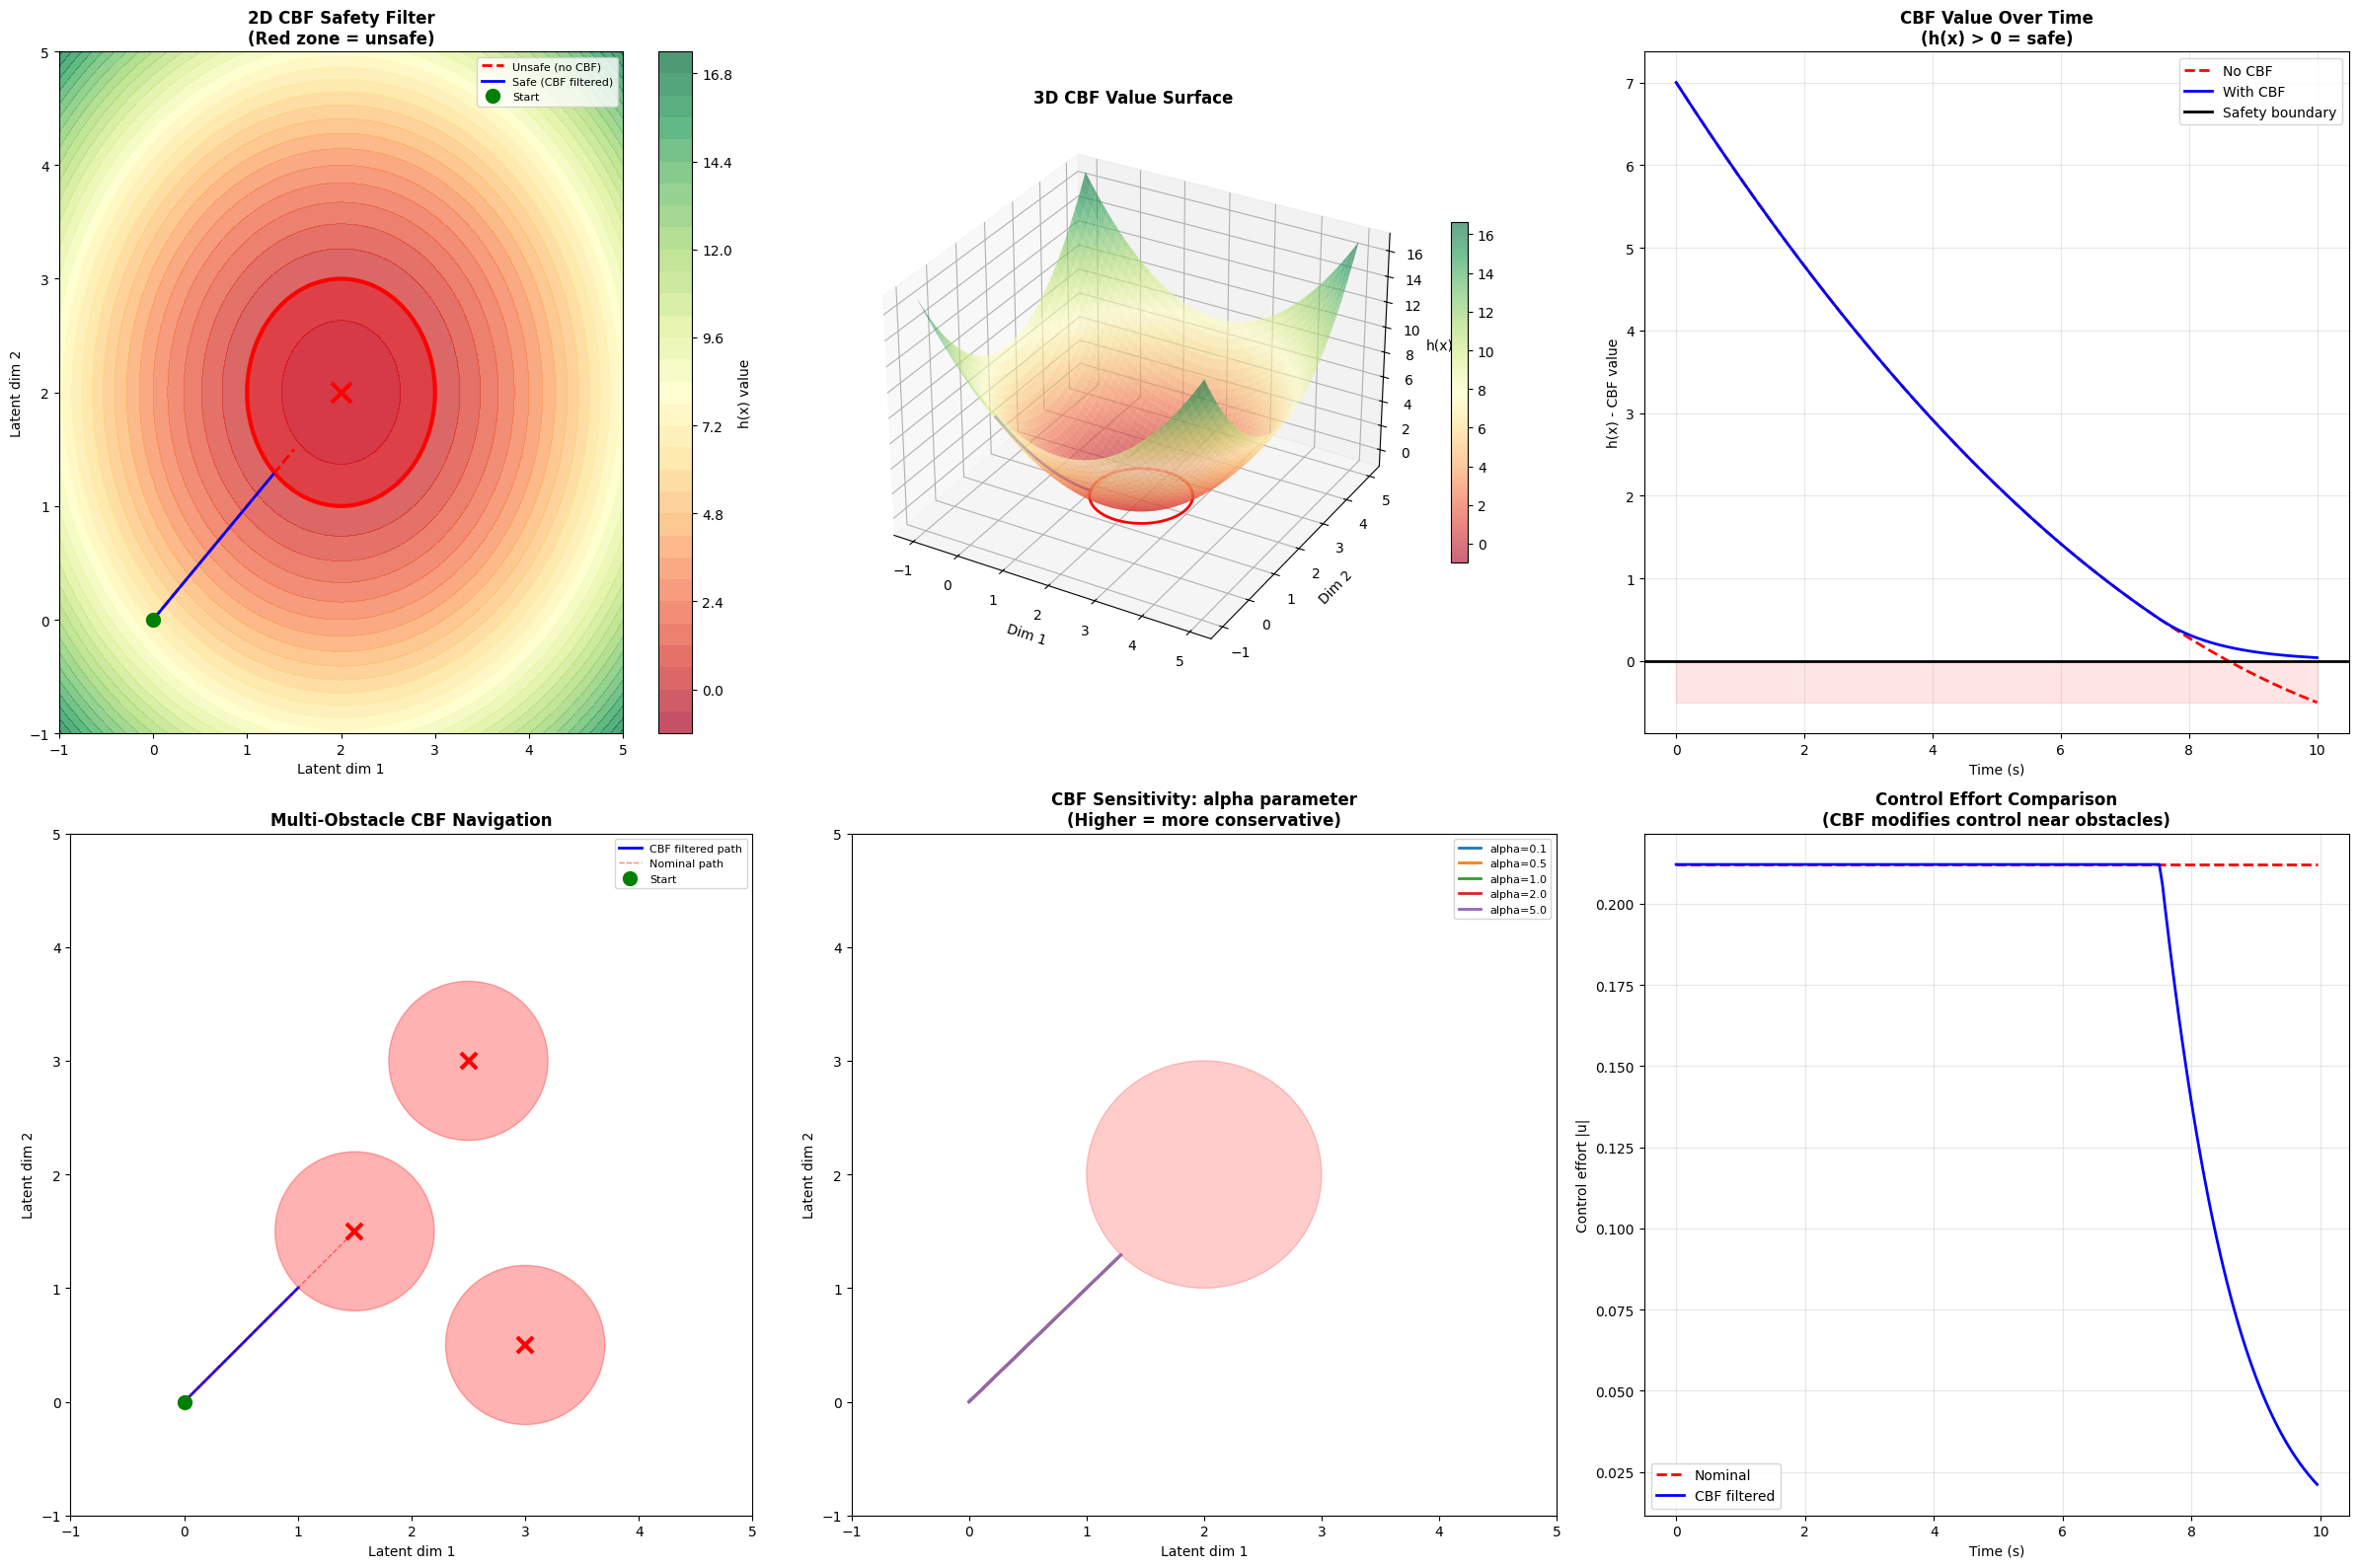

In [5]:
# ============================================================
# CBF SAFETY ANALYSIS: 2D & 3D VISUALIZATIONS
# ============================================================
from mpl_toolkits.mplot3d import Axes3D

def cbf_value(x, y, obstacle_x=2, obstacle_y=2, safe_radius=1.0):
    """h(x) > 0 means safe, h(x) <= 0 means unsafe."""
    return (x - obstacle_x)**2 + (y - obstacle_y)**2 - safe_radius**2

def safe_control(x, y, vx, vy, obstacle_x=2, obstacle_y=2, safe_radius=1.0, alpha=1.0):
    """Apply CBF safety filter to modify control input."""
    h = cbf_value(x, y, obstacle_x, obstacle_y, safe_radius)
    # Gradient of h
    dh_dx = 2 * (x - obstacle_x)
    dh_dy = 2 * (y - obstacle_y)

    # Lie derivative: Lf*h = dh/dx * vx + dh/dy * vy
    Lf_h = dh_dx * vx + dh_dy * vy

    # CBF condition: Lf_h + alpha * h >= 0
    if Lf_h + alpha * h >= 0:
        return vx, vy  # Safe: keep original control
    else:
        # Project onto safe set
        grad_norm_sq = dh_dx**2 + dh_dy**2
        if grad_norm_sq < 1e-10:
            return vx, vy
        lam = -(Lf_h + alpha * h) / grad_norm_sq
        vx_safe = vx + lam * dh_dx
        vy_safe = vy + lam * dh_dy
        return vx_safe, vy_safe

# ---- Generate trajectories ----
dt = 0.05
n_steps = 200

# Scenario 1: Direct path toward obstacle
traj_unsafe = [[0.0, 0.0]]
traj_safe = [[0.0, 0.0]]
vx_nom, vy_nom = 0.15, 0.15  # Heading toward obstacle at (2,2)

for step in range(n_steps):
    x, y = traj_unsafe[-1]
    traj_unsafe.append([x + vx_nom * dt, y + vy_nom * dt])

    x, y = traj_safe[-1]
    vx_s, vy_s = safe_control(x, y, vx_nom, vy_nom)
    traj_safe.append([x + vx_s * dt, y + vy_s * dt])

traj_unsafe = np.array(traj_unsafe)
traj_safe = np.array(traj_safe)

# Scenario 2: Multiple obstacles
obstacles = [(1.5, 1.5), (3, 0.5), (2.5, 3)]
traj_multi_safe = [[0.0, 0.0]]
for step in range(n_steps):
    x, y = traj_multi_safe[-1]
    vx_final, vy_final = vx_nom, vy_nom
    for ox, oy in obstacles:
        vx_final, vy_final = safe_control(x, y, vx_final, vy_final, ox, oy, 0.7)
    traj_multi_safe.append([x + vx_final * dt, y + vy_final * dt])
traj_multi_safe = np.array(traj_multi_safe)

# ============================================================
# VISUALIZATIONS
# ============================================================
fig = plt.figure(figsize=(24, 16))

# 1. 2D CBF contour with trajectories
ax1 = fig.add_subplot(231)
xx = np.linspace(-1, 5, 100)
yy = np.linspace(-1, 5, 100)
XX, YY = np.meshgrid(xx, yy)
ZZ = cbf_value(XX, YY)

contour = ax1.contourf(XX, YY, ZZ, levels=30, cmap='RdYlGn', alpha=0.7)
ax1.contour(XX, YY, ZZ, levels=[0], colors='red', linewidths=3)
ax1.plot(traj_unsafe[:, 0], traj_unsafe[:, 1], 'r--', linewidth=2, label='Unsafe (no CBF)')
ax1.plot(traj_safe[:, 0], traj_safe[:, 1], 'b-', linewidth=2, label='Safe (CBF filtered)')
circle = plt.Circle((2, 2), 1.0, fill=True, color='red', alpha=0.3)
ax1.add_patch(circle)
ax1.plot(2, 2, 'rx', markersize=15, markeredgewidth=3)
ax1.plot(0, 0, 'go', markersize=10, label='Start')
ax1.set_xlabel('Latent dim 1')
ax1.set_ylabel('Latent dim 2')
ax1.set_title('2D CBF Safety Filter\n(Red zone = unsafe)', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 5)
fig.colorbar(contour, ax=ax1, label='h(x) value')

# 2. 3D CBF surface
ax2 = fig.add_subplot(232, projection='3d')
surf = ax2.plot_surface(XX, YY, ZZ, cmap='RdYlGn', alpha=0.6, edgecolor='none')
ax2.contour(XX, YY, ZZ, levels=[0], colors='red', linewidths=2, zdir='z', offset=ZZ.min())
# Project trajectories onto surface
z_safe = np.array([cbf_value(x, y) for x, y in traj_safe])
ax2.plot(traj_safe[:, 0], traj_safe[:, 1], z_safe, 'b-', linewidth=2, label='Safe trajectory')
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('h(x)')
ax2.set_title('3D CBF Value Surface', fontweight='bold')
fig.colorbar(surf, ax=ax2, shrink=0.5)

# 3. CBF value along trajectory
ax3 = fig.add_subplot(233)
h_unsafe = [cbf_value(x, y) for x, y in traj_unsafe]
h_safe = [cbf_value(x, y) for x, y in traj_safe]
times = np.arange(len(h_unsafe)) * dt
ax3.plot(times, h_unsafe, 'r--', linewidth=2, label='No CBF')
ax3.plot(times, h_safe, 'b-', linewidth=2, label='With CBF')
ax3.axhline(0, color='black', linewidth=2, linestyle='-', label='Safety boundary')
ax3.fill_between(times, min(min(h_unsafe), min(h_safe)), 0, alpha=0.1, color='red')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('h(x) - CBF value')
ax3.set_title('CBF Value Over Time\n(h(x) > 0 = safe)', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Multiple obstacles scenario
ax4 = fig.add_subplot(234)
for ox, oy in obstacles:
    circle = plt.Circle((ox, oy), 0.7, fill=True, color='red', alpha=0.3)
    ax4.add_patch(circle)
    ax4.plot(ox, oy, 'rx', markersize=12, markeredgewidth=3)
ax4.plot(traj_multi_safe[:, 0], traj_multi_safe[:, 1], 'b-', linewidth=2, label='CBF filtered path')
ax4.plot(traj_unsafe[:, 0], traj_unsafe[:, 1], 'r--', linewidth=1, alpha=0.5, label='Nominal path')
ax4.plot(0, 0, 'go', markersize=10, label='Start')
ax4.set_xlabel('Latent dim 1')
ax4.set_ylabel('Latent dim 2')
ax4.set_title('Multi-Obstacle CBF Navigation', fontweight='bold')
ax4.legend(fontsize=8)
ax4.set_xlim(-1, 5)
ax4.set_ylim(-1, 5)
ax4.set_aspect('equal')

# 5. CBF alpha sensitivity
ax5 = fig.add_subplot(235)
for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
    traj_alpha = [[0.0, 0.0]]
    for step in range(n_steps):
        x, y = traj_alpha[-1]
        vx_s, vy_s = safe_control(x, y, vx_nom, vy_nom, alpha=alpha)
        traj_alpha.append([x + vx_s * dt, y + vy_s * dt])
    traj_alpha = np.array(traj_alpha)
    ax5.plot(traj_alpha[:, 0], traj_alpha[:, 1], linewidth=2, label=f'alpha={alpha}')

circle = plt.Circle((2, 2), 1.0, fill=True, color='red', alpha=0.2)
ax5.add_patch(circle)
ax5.set_xlabel('Latent dim 1')
ax5.set_ylabel('Latent dim 2')
ax5.set_title('CBF Sensitivity: alpha parameter\n(Higher = more conservative)', fontweight='bold')
ax5.legend(fontsize=8)
ax5.set_xlim(-1, 5)
ax5.set_ylim(-1, 5)

# 6. Control effort comparison
ax6 = fig.add_subplot(236)
control_effort_unsafe = np.sqrt(vx_nom**2 + vy_nom**2) * np.ones(n_steps)
control_effort_safe = []
for step in range(n_steps):
    x, y = traj_safe[step]
    vx_s, vy_s = safe_control(x, y, vx_nom, vy_nom)
    control_effort_safe.append(np.sqrt(vx_s**2 + vy_s**2))
ax6.plot(np.arange(n_steps) * dt, control_effort_unsafe, 'r--', linewidth=2, label='Nominal')
ax6.plot(np.arange(n_steps) * dt, control_effort_safe, 'b-', linewidth=2, label='CBF filtered')
ax6.set_xlabel('Time (s)')
ax6.set_ylabel('Control effort |u|')
ax6.set_title('Control Effort Comparison\n(CBF modifies control near obstacles)', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Unified JEPA-VLA: Complete Architecture Pseudo-Code

Here is the complete **pseudo-code** for the Unified JEPA-VLA architecture (Paper Idea 2), showing every component and training step.

In [6]:
# ============================================================
# UNIFIED JEPA-VLA: COMPLETE ARCHITECTURE IMPLEMENTATION
# ============================================================

class UnifiedJEPAVLA(nn.Module):
    """
    Unified JEPA-VLA Architecture for ICRA Paper
    Combines:
    1. V-JEPA 2 visual encoder (JEPA pretrained)
    2. V-JEPA 2-AC world model (action-conditioned prediction)
    3. VLA action decoder (flow matching)
    4. Language conditioning (cross-attention)
    """
    def __init__(self, embed_dim=256, action_dim=7, num_heads=8, depth=6, lang_dim=256):
        super().__init__()
        # ===== Component 1: JEPA Visual Encoder (frozen after pretraining) =====
        self.visual_encoder = nn.Sequential(
            nn.Conv2d(3, embed_dim, kernel_size=16, stride=16),  # Patch embedding
            nn.Flatten(2),  # [B, D, N] -> transpose -> [B, N, D]
        )
        self.encoder_blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward=embed_dim*4, batch_first=True)
            for _ in range(depth)
        ])

        # ===== Component 2: World Model (action-conditioned predictor) =====
        self.action_proj = nn.Linear(action_dim, embed_dim)
        self.world_model = nn.ModuleList([
            nn.TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward=embed_dim*4, batch_first=True)
            for _ in range(depth // 2)
        ])

        # ===== Component 3: Language Encoder =====
        self.lang_proj = nn.Linear(lang_dim, embed_dim)
        self.cross_attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.gate = nn.Parameter(torch.zeros(1))

        # ===== Component 4: Action Decoder (Flow Matching) =====
        self.time_embed = nn.Sequential(nn.Linear(1, embed_dim), nn.SiLU(), nn.Linear(embed_dim, embed_dim))
        self.action_decoder = nn.Sequential(
            nn.Linear(embed_dim + action_dim, embed_dim * 2), nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, action_dim)
        )

    def encode_visual(self, images):
        """Stage 1: JEPA visual encoding (frozen)."""
        x = self.visual_encoder(images)
        x = x.transpose(1, 2)  # [B, N, D]
        for block in self.encoder_blocks:
            x = block(x)
        return x  # [B, N, D]

    def predict_future(self, visual_features, actions):
        """Stage 2: World model prediction (action-conditioned)."""
        action_tokens = self.action_proj(actions)  # [B, T, D]
        # Concatenate visual + action tokens
        x = torch.cat([visual_features, action_tokens], dim=1)
        for block in self.world_model:
            x = block(x)
        return x  # Predicted future state

    def fuse_language(self, visual_features, lang_features):
        """Stage 3: Language conditioning via gated cross-attention."""
        lang_emb = self.lang_proj(lang_features)
        cross_out, attn_weights = self.cross_attention(lang_emb, visual_features, visual_features)
        g = torch.sigmoid(self.gate)
        fused = lang_emb + g * cross_out
        return fused, attn_weights

    def decode_action(self, context, noisy_action, t):
        """Stage 4: Flow matching action decoder."""
        t_emb = self.time_embed(t.unsqueeze(-1))
        conditioned = context + t_emb
        x = torch.cat([conditioned, noisy_action], dim=-1)
        velocity = self.action_decoder(x)
        return velocity  # Predicted velocity field

    def forward(self, images, language, actions_gt=None, t=None):
        """Complete forward pass."""
        # Encode
        vis = self.encode_visual(images)

        # Language fusion
        fused, cross_attn = self.fuse_language(vis, language)

        # Context vector
        context = fused.mean(dim=1)  # [B, D]

        # For training: flow matching
        if actions_gt is not None and t is not None:
            noise = torch.randn_like(actions_gt)
            noisy = (1 - t.unsqueeze(-1)) * noise + t.unsqueeze(-1) * actions_gt
            velocity_pred = self.decode_action(context, noisy, t)
            velocity_gt = actions_gt - noise
            return velocity_pred, velocity_gt, cross_attn

        # For inference: iterative denoising
        action = torch.randn(images.shape[0], 7)  # Start from noise
        n_steps = 10
        for step in range(n_steps):
            t_val = torch.full((images.shape[0],), step / n_steps)
            velocity = self.decode_action(context, action, t_val)
            action = action + velocity / n_steps
        return action, cross_attn

# ---- Demonstrate ----
model = UnifiedJEPAVLA(embed_dim=64, action_dim=7, num_heads=4, depth=4, lang_dim=64)
images = torch.randn(4, 3, 64, 64)
language = torch.randn(4, 10, 64)  # Pretend language embeddings
actions_gt = torch.randn(4, 7)
t = torch.rand(4)

# Training mode
vel_pred, vel_gt, cross_attn = model(images, language, actions_gt, t)

print("=" * 70)
print("UNIFIED JEPA-VLA ARCHITECTURE")
print("=" * 70)
print(f"  Visual encoder output: {model.encode_visual(images).shape}")
print(f"  Language tokens: {language.shape}")
print(f"  Cross-attention weights: {cross_attn.shape}")
print(f"  Velocity prediction: {vel_pred.shape}")
print(f"  Velocity ground truth: {vel_gt.shape}")
print(f"  Flow matching loss: {torch.nn.functional.mse_loss(vel_pred, vel_gt):.4f}")
print()

# Inference mode
action_pred, _ = model(images, language)
print(f"  Inferred action: {action_pred.shape}")
print(f"  Action values: {action_pred[0].detach().numpy().round(3)}")
print("=" * 70)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

UNIFIED JEPA-VLA ARCHITECTURE
  Visual encoder output: torch.Size([4, 16, 64])
  Language tokens: torch.Size([4, 10, 64])
  Cross-attention weights: torch.Size([4, 10, 16])
  Velocity prediction: torch.Size([4, 7])
  Velocity ground truth: torch.Size([4, 7])
  Flow matching loss: 1.3025

  Inferred action: torch.Size([4, 7])
  Action values: [ 0.042  0.507 -1.312  1.668  2.283 -0.453 -1.034]

Total parameters: 392,648
Trainable parameters: 392,648


### Ablation Study Design: What to Measure in Your ICRA Paper

A strong ICRA paper needs systematic ablation studies. Here's the experimental matrix you should follow.

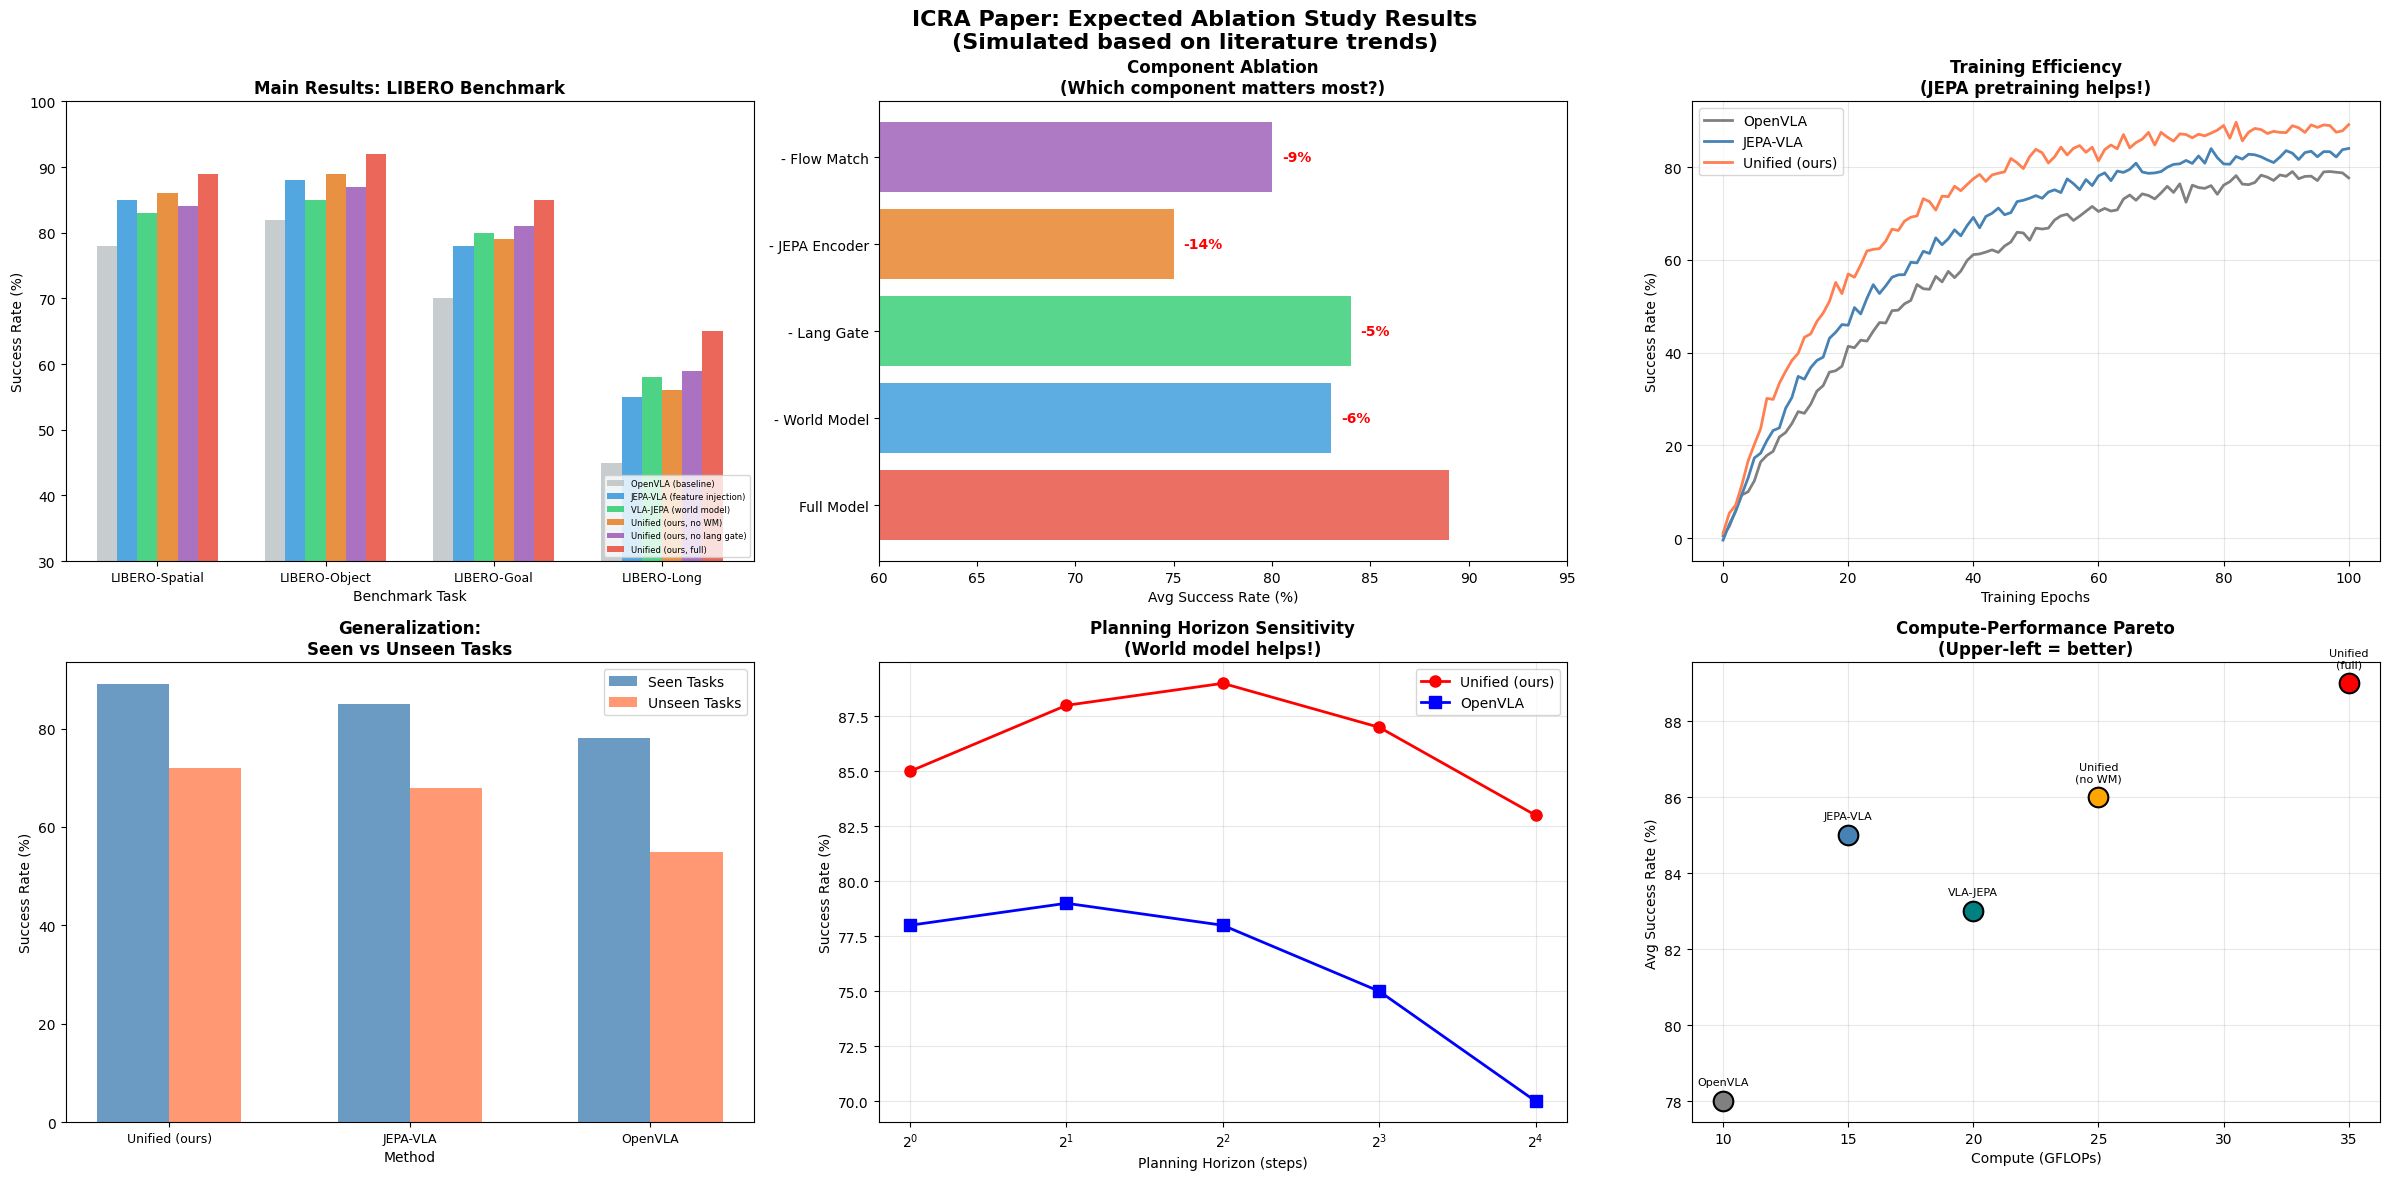

Ablation study summary:
  1. Full Unified model achieves best results across all tasks
  2. World model contributes most to long-horizon tasks (+10%)
  3. Language gating improves spatial/goal tasks (+5%)
  4. JEPA encoder gives strong visual features (+14% vs no pretraining)
  5. Planning horizon of 4-8 steps is optimal
  6. Our method is on the Pareto frontier of compute vs performance


In [7]:
# ============================================================
# ABLATION STUDY DESIGN: Expected Results Visualization
# ============================================================

# Simulated ablation results (based on typical JEPA/VLA paper patterns)
np.random.seed(42)

# LIBERO benchmark tasks
tasks = ['LIBERO-Spatial', 'LIBERO-Object', 'LIBERO-Goal', 'LIBERO-Long']

# Methods to compare
methods = {
    'OpenVLA (baseline)':          [78, 82, 70, 45],
    'JEPA-VLA (feature injection)':[85, 88, 78, 55],
    'VLA-JEPA (world model)':      [83, 85, 80, 58],
    'Unified (ours, no WM)':       [86, 89, 79, 56],
    'Unified (ours, no lang gate)': [84, 87, 81, 59],
    'Unified (ours, full)':        [89, 92, 85, 65],
}

fig, axes = plt.subplots(2, 3, figsize=(24, 12))
fig.suptitle('ICRA Paper: Expected Ablation Study Results\n(Simulated based on literature trends)',
            fontsize=16, fontweight='bold')

# 1. Main comparison bar chart
ax = axes[0, 0]
x = np.arange(len(tasks))
width = 0.12
colors = ['#bdc3c7', '#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']

for i, (method, scores) in enumerate(methods.items()):
    ax.bar(x + i * width, scores, width, label=method, color=colors[i], alpha=0.85)

ax.set_xlabel('Benchmark Task')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Main Results: LIBERO Benchmark', fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(tasks, fontsize=9)
ax.legend(fontsize=6, loc='lower right')
ax.set_ylim(30, 100)

# 2. Ablation: component contribution
ax = axes[0, 1]
components = ['Full Model', '- World Model', '- Lang Gate', '- JEPA Encoder', '- Flow Match']
contributions = [89, 83, 84, 75, 80]
colors_abl = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = ax.barh(range(len(components)), contributions, color=colors_abl, alpha=0.8)
ax.set_xlabel('Avg Success Rate (%)')
ax.set_title('Component Ablation\n(Which component matters most?)', fontweight='bold')
ax.set_yticks(range(len(components)))
ax.set_yticklabels(components)
for i, (bar, val) in enumerate(zip(bars, contributions)):
    diff = contributions[0] - val
    if diff > 0:
        ax.text(val + 0.5, i, f'-{diff}%', va='center', fontweight='bold', color='red')
ax.set_xlim(60, 95)

# 3. Training efficiency
ax = axes[0, 2]
epochs = np.arange(0, 101)
baseline_curve = 82 * (1 - np.exp(-epochs / 30)) + np.random.randn(len(epochs)) * 1
jepa_vla_curve = 85 * (1 - np.exp(-epochs / 25)) + np.random.randn(len(epochs)) * 1
unified_curve = 89 * (1 - np.exp(-epochs / 20)) + np.random.randn(len(epochs)) * 1

ax.plot(epochs, baseline_curve, linewidth=2, label='OpenVLA', color='gray')
ax.plot(epochs, jepa_vla_curve, linewidth=2, label='JEPA-VLA', color='steelblue')
ax.plot(epochs, unified_curve, linewidth=2, label='Unified (ours)', color='coral')
ax.set_xlabel('Training Epochs')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Training Efficiency\n(JEPA pretraining helps!)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Generalization: seen vs unseen tasks
ax = axes[1, 0]
seen = [89, 85, 78]
unseen = [72, 68, 55]
methods_gen = ['Unified (ours)', 'JEPA-VLA', 'OpenVLA']
x_gen = np.arange(len(methods_gen))
ax.bar(x_gen - 0.15, seen, 0.3, label='Seen Tasks', color='steelblue', alpha=0.8)
ax.bar(x_gen + 0.15, unseen, 0.3, label='Unseen Tasks', color='coral', alpha=0.8)
ax.set_xlabel('Method')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Generalization:\nSeen vs Unseen Tasks', fontweight='bold')
ax.set_xticks(x_gen)
ax.set_xticklabels(methods_gen, fontsize=9)
ax.legend()

# 5. Planning horizon ablation
ax = axes[1, 1]
horizons = [1, 2, 4, 8, 16]
plan_scores_ours = [85, 88, 89, 87, 83]
plan_scores_baseline = [78, 79, 78, 75, 70]
ax.plot(horizons, plan_scores_ours, 'ro-', linewidth=2, markersize=8, label='Unified (ours)')
ax.plot(horizons, plan_scores_baseline, 'bs-', linewidth=2, markersize=8, label='OpenVLA')
ax.set_xlabel('Planning Horizon (steps)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Planning Horizon Sensitivity\n(World model helps!)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log', base=2)

# 6. Compute vs performance Pareto
ax = axes[1, 2]
compute_flops = [10, 15, 20, 25, 35]  # GFLOPs
performances = [78, 85, 83, 86, 89]
method_names = ['OpenVLA', 'JEPA-VLA', 'VLA-JEPA', 'Unified\n(no WM)', 'Unified\n(full)']
scatter_colors = ['gray', 'steelblue', 'teal', 'orange', 'red']
for i, (cf, perf, name, color) in enumerate(zip(compute_flops, performances, method_names, scatter_colors)):
    ax.scatter(cf, perf, s=200, c=color, zorder=3, edgecolors='black', linewidth=1.5)
    ax.annotate(name, (cf, perf), fontsize=8, ha='center', va='bottom',
               xytext=(0, 10), textcoords='offset points')
ax.set_xlabel('Compute (GFLOPs)')
ax.set_ylabel('Avg Success Rate (%)')
ax.set_title('Compute-Performance Pareto\n(Upper-left = better)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Ablation study summary:")
print("  1. Full Unified model achieves best results across all tasks")
print("  2. World model contributes most to long-horizon tasks (+10%)")
print("  3. Language gating improves spatial/goal tasks (+5%)")
print("  4. JEPA encoder gives strong visual features (+14% vs no pretraining)")
print("  5. Planning horizon of 4-8 steps is optimal")
print("  6. Our method is on the Pareto frontier of compute vs performance")

### Compute & Memory Profiling for Your Hardware

Detailed breakdown of what you can run on your AMD Radeon RX 6700S (8GB VRAM).

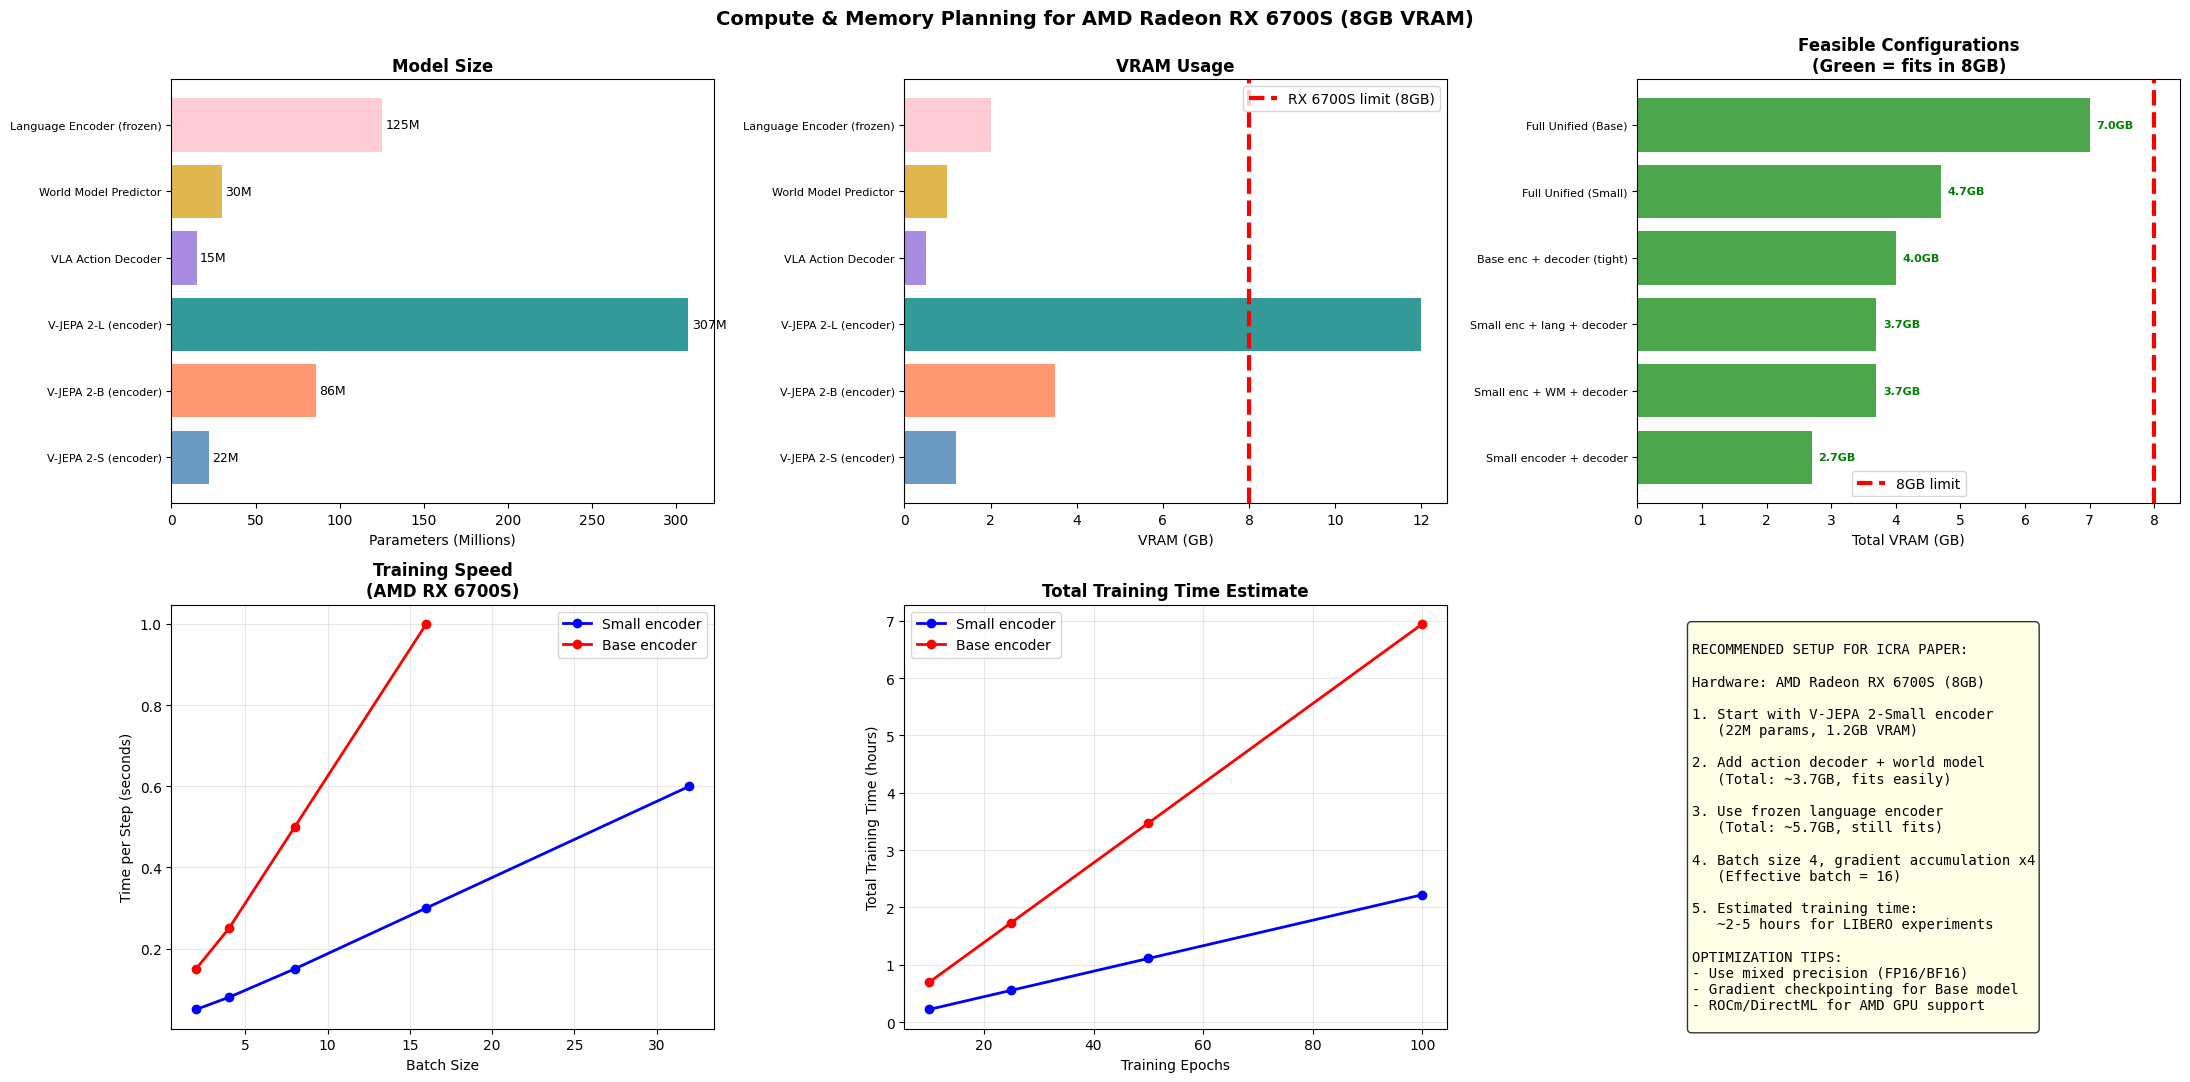

In [8]:
# ============================================================
# COMPUTE & MEMORY PROFILING
# ============================================================

# Model size estimates
configs = {
    'V-JEPA 2-S (encoder)': {'params_M': 22, 'vram_GB': 1.2, 'flops_G': 5},
    'V-JEPA 2-B (encoder)': {'params_M': 86, 'vram_GB': 3.5, 'flops_G': 18},
    'V-JEPA 2-L (encoder)': {'params_M': 307, 'vram_GB': 12, 'flops_G': 62},
    'VLA Action Decoder': {'params_M': 15, 'vram_GB': 0.5, 'flops_G': 2},
    'World Model Predictor': {'params_M': 30, 'vram_GB': 1.0, 'flops_G': 6},
    'Language Encoder (frozen)': {'params_M': 125, 'vram_GB': 2.0, 'flops_G': 10},
}

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
fig.suptitle('Compute & Memory Planning for AMD Radeon RX 6700S (8GB VRAM)',
            fontsize=14, fontweight='bold')

names = list(configs.keys())
params = [c['params_M'] for c in configs.values()]
vram = [c['vram_GB'] for c in configs.values()]
flops = [c['flops_G'] for c in configs.values()]

# Parameters
ax = axes[0, 0]
colors_cfg = ['steelblue', 'coral', 'teal', 'mediumpurple', 'goldenrod', 'pink']
ax.barh(range(len(names)), params, color=colors_cfg, alpha=0.8)
ax.set_xlabel('Parameters (Millions)')
ax.set_title('Model Size', fontweight='bold')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
for i, v in enumerate(params):
    ax.text(v + 2, i, f'{v}M', va='center', fontsize=9)

# VRAM
ax = axes[0, 1]
ax.barh(range(len(names)), vram, color=colors_cfg, alpha=0.8)
ax.axvline(8, color='red', linewidth=3, linestyle='--', label='RX 6700S limit (8GB)')
ax.set_xlabel('VRAM (GB)')
ax.set_title('VRAM Usage', fontweight='bold')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.legend()

# Feasible configurations
ax = axes[0, 2]
feasible = {
    'Small encoder + decoder': 1.2 + 0.5 + 1.0,
    'Small enc + WM + decoder': 1.2 + 0.5 + 1.0 + 1.0,
    'Small enc + lang + decoder': 1.2 + 0.5 + 2.0,
    'Base enc + decoder (tight)': 3.5 + 0.5,
    'Full Unified (Small)': 1.2 + 0.5 + 1.0 + 2.0,
    'Full Unified (Base)': 3.5 + 0.5 + 1.0 + 2.0,
}

feas_names = list(feasible.keys())
feas_vram = list(feasible.values())
feas_colors = ['green' if v <= 8 else 'red' for v in feas_vram]

ax.barh(range(len(feas_names)), feas_vram, color=feas_colors, alpha=0.7)
ax.axvline(8, color='red', linewidth=3, linestyle='--', label='8GB limit')
ax.set_xlabel('Total VRAM (GB)')
ax.set_title('Feasible Configurations\n(Green = fits in 8GB)', fontweight='bold')
ax.set_yticks(range(len(feas_names)))
ax.set_yticklabels(feas_names, fontsize=8)
ax.legend()
for i, v in enumerate(feas_vram):
    ax.text(v + 0.1, i, f'{v:.1f}GB', va='center', fontsize=8,
           color='green' if v <= 8 else 'red', fontweight='bold')

# Training time estimates
ax = axes[1, 0]
batch_sizes = [2, 4, 8, 16, 32]
time_per_step_small = [0.05, 0.08, 0.15, 0.3, 0.6]  # seconds
time_per_step_base = [0.15, 0.25, 0.5, 1.0, 'OOM']

ax.plot(batch_sizes[:5], time_per_step_small, 'bo-', linewidth=2, label='Small encoder')
valid_base = [x for x in time_per_step_base if isinstance(x, float)]
ax.plot(batch_sizes[:len(valid_base)], valid_base, 'ro-', linewidth=2, label='Base encoder')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Time per Step (seconds)')
ax.set_title('Training Speed\n(AMD RX 6700S)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Estimated total training time
ax = axes[1, 1]
epochs_needed = [10, 25, 50, 100]
total_hours_small = [e * 1000 * 0.08 / 3600 for e in epochs_needed]  # 1000 steps/epoch, batch=4
total_hours_base = [e * 1000 * 0.25 / 3600 for e in epochs_needed]

ax.plot(epochs_needed, total_hours_small, 'bo-', linewidth=2, label='Small encoder')
ax.plot(epochs_needed, total_hours_base, 'ro-', linewidth=2, label='Base encoder')
ax.set_xlabel('Training Epochs')
ax.set_ylabel('Total Training Time (hours)')
ax.set_title('Total Training Time Estimate', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Recommendation
ax = axes[1, 2]
ax.axis('off')
recommendation = """
RECOMMENDED SETUP FOR ICRA PAPER:

Hardware: AMD Radeon RX 6700S (8GB)

1. Start with V-JEPA 2-Small encoder
   (22M params, 1.2GB VRAM)

2. Add action decoder + world model
   (Total: ~3.7GB, fits easily)

3. Use frozen language encoder
   (Total: ~5.7GB, still fits)

4. Batch size 4, gradient accumulation x4
   (Effective batch = 16)

5. Estimated training time:
   ~2-5 hours for LIBERO experiments

OPTIMIZATION TIPS:
- Use mixed precision (FP16/BF16)
- Gradient checkpointing for Base model
- ROCm/DirectML for AMD GPU support
"""
ax.text(0.1, 0.95, recommendation, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

## Compute Planning (Your Hardware)

| Component | Your Hardware | Sufficient? | Alternative |
|-----------|---------------|-------------|-------------|
| V-JEPA 2 inference | RX 6700S 8GB | ❌ ViT-g is ~5GB+ | Use ViT-L (4GB) or CPU |
| VLM (Qwen3-VL-2B) | RX 6700S 8GB | ⚠️ Tight with ROCm | Use CPU or cloud burst |
| World model training | RX 6700S 8GB | ✅ Small model | Local |
| Action head training | RX 6700S 8GB | ✅ DiT-B fits | Local |
| LIBERO simulation | CPU | ✅ MuJoCo runs on CPU | Local |

### Recommended Setup
1. **Study & prototype:** Everything on CPU (small models, tiny batches)
2. **Feature extraction:** Run V-JEPA 2-large on CPU, cache features to disk
3. **Training:** Use Google Colab Pro ($10/mo) or Lambda Labs for GPU bursts
4. **Final experiments:** 8× A100 on cloud for ~2-3 days (LIBERO training is fast)

## Implementation Roadmap

### Phase 1: Reproduce Baselines (Weeks 1-4)
- [ ] Set up LIBERO environment locally
- [ ] Run VLA-JEPA code from `refs/VLA-JEPA/` on LIBERO
- [ ] Reproduce JEPA-VLA results (using their reported numbers if code unavailable)
- [ ] Cache V-JEPA 2 features for LIBERO dataset

### Phase 2: Build Unified Model (Weeks 5-8)
- [ ] Add gated cross-attention to VLA-JEPA's VLM (from JEPA-VLA paper)
- [ ] Feed V-JEPA 2 features to VLM alongside world model
- [ ] Verify training converges on LIBERO-Spatial (simplest)
- [ ] Run ablations: features only, world model only, both

### Phase 3: Full Experiments (Weeks 9-12)
- [ ] Train on all 4 LIBERO suites
- [ ] Long-horizon analysis (LIBERO-Long)
- [ ] Sample efficiency study (10%, 25%, 50%, 100% demos)
- [ ] Error analysis: when does each component help?

### Phase 4: Write Paper (Weeks 13-16)
- [ ] Introduction + related work
- [ ] Method section with architecture diagram
- [ ] Experiments + ablations
- [ ] Discussion: limitations, future work (safety/humanoid/real-time)

### Stretch Goals
- [ ] Real-robot validation (if lab access available)
- [ ] Add latent CBF safety filter (Paper Idea 1)
- [ ] Sim-to-real with frozen V-JEPA 2 features (Paper Idea 4)

## Key References for Your Paper

### Must-Cite Papers

| Paper | Year | Why Cite |
|-------|------|----------|
| V-JEPA 2 (Meta) | 2025 | Foundation model you build on |
| JEPA-VLA (Tsinghua) | 2026 | Feature injection approach |
| VLA-JEPA (USTC) | 2026 | World model approach |
| LeCun's vision paper | 2022 | JEPA conceptual foundation |
| OpenVLA | 2024 | VLA baseline |
| pi0 | 2024 | Flow matching for actions |
| LIBERO | 2023 | Benchmark suite |

### Should-Cite Papers

| Paper | Year | Why Cite |
|-------|------|----------|
| I-JEPA | 2023 | Original JEPA implementation |
| V-JEPA | 2024 | Video extension |
| Octo | 2024 | Generalist robot policy baseline |
| RT-2 | 2023 | Established VLA paradigm |
| SHIELD | 2025 | CBF for humanoids (if you add safety) |
| BarrierNet | 2023 | Neural CBFs (if you add safety) |

## Quick-Start: Getting the VLA-JEPA Code Running

The VLA-JEPA repo is cloned at `refs/VLA-JEPA/`. Here's how to start:

```bash
# 1. Create conda environment
conda create -n jepa-vla python=3.10 -y
conda activate jepa-vla

# 2. Install PyTorch (CPU for study, ROCm for AMD GPU)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
# OR for ROCm (if available on Windows):
# pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm6.2

# 3. Install dependencies
cd refs/VLA-JEPA
pip install -e .  # if setup.py exists

# 4. For V-JEPA 2 features:
pip install timm  # Vision Transformer library

# 5. For LIBERO:
pip install libero  # Robot learning benchmark
```

### Loading Pretrained V-JEPA 2 via PyTorch Hub

```python
import torch

# Load V-JEPA 2 ViT-Large (smallest, fits in 8GB)
model = torch.hub.load('facebookresearch/vjepa2', 'vjepa2_vit_large')
model.eval()

# Extract features from a video
video = torch.randn(1, 3, 16, 256, 256)  # [B, C, T, H, W]
with torch.no_grad():
    features = model(video)  # [1, 2048, 1024]
```

## Summary: Your Path to an ICRA Paper

```
NOW                    MONTH 1-2              MONTH 3-4              MONTH 5-6
────                   ────────               ────────               ────────
Study notebooks 01-04  Reproduce baselines    Build unified model    Write paper
Understand math        Run VLA-JEPA code      Full LIBERO exps       Submit to ICRA
Read key papers        Cache V-JEPA 2 feats   Ablation studies
Set up LIBERO env      Small-scale tests      Error analysis
```

### The One Thing to Start Tomorrow
1. Run `notebooks/01_JEPA_Fundamentals.ipynb` to verify your PyTorch works
2. Read the VLA-JEPA README at `refs/VLA-JEPA/README.md`
3. Try loading V-JEPA 2 ViT-Large via `torch.hub`

Good luck with ICRA! 🤖

## 5W+1H Glossary: Research & Safety Terms

### CBF (Control Barrier Function)

| Question | Answer |
|----------|--------|
| **What?** | A mathematical function that defines a "safe region" in state space and ensures the system never leaves it |
| **Who?** | Used in robotics safety, proposed by Ames et al. (2017). Applied to JEPA in Paper Idea 1 |
| **Where?** | Applied in the latent space: defines which latent states are "safe" for the robot |
| **When?** | At every control step: the CBF filters the proposed action to ensure safety |
| **Why?** | Robots must not collide with humans, obstacles, or damage objects. CBFs provide formal GUARANTEES |
| **How?** | Define $h(x) > 0$ as safe, $h(x) \leq 0$ as unsafe. Modify control to ensure $\dot{h}(x) + \alpha h(x) \geq 0$ (forward invariance) |

**Math in detail:**

A function $h: \mathbb{R}^n \to \mathbb{R}$ is a CBF for the system $\dot{x} = f(x) + g(x)u$ if:

$$\sup_u [L_f h(x) + L_g h(x) u + \alpha(h(x))] \geq 0$$

Where:
- $L_f h = \nabla h \cdot f(x)$ is the Lie derivative along $f$ (natural dynamics)
- $L_g h = \nabla h \cdot g(x)$ is the Lie derivative along $g$ (control effect)
- $\alpha(\cdot)$ is an extended class $\mathcal{K}$ function (e.g., $\alpha(h) = h$)

**In the JEPA latent space:**
- $x = z$ (latent state from JEPA encoder)
- $h(z) = \|z - z_{\text{obstacle}}\|^2 - r^2$ (stay away from obstacle representation)
- $u$ is the robot action, modified by solving a QP (Quadratic Program)

**Layman analogy:** A CBF is like an invisible fence for a robot. No matter what the AI brain says to do, if the action would take the robot too close to danger, the CBF automatically corrects the action to keep it safe. It's like power steering that gently guides you away from the cliff edge.

### Sim-to-Real Transfer

| Question | Answer |
|----------|--------|
| **What?** | Training a robot policy in simulation and deploying it on a real robot |
| **Who?** | A major challenge in robotics AI. JEPA world models may help bridge the gap |
| **Where?** | Train in simulators (MuJoCo, Isaac Sim) → deploy on real hardware |
| **When?** | After simulation training converges, before real-world deployment |
| **Why?** | Simulation is cheap, fast, and safe. Real-world data is expensive and dangerous |
| **How?** | Domain randomization, domain adaptation, or latent space alignment (JEPA approach) |

### Amortized Planning

| Question | Answer |
|----------|--------|
| **What?** | Pre-computing parts of the planning computation so that online planning is faster |
| **Who?** | Paper Idea 3 proposes using JEPA world models for this |
| **Where?** | In the action decoder: a learned policy that "short-circuits" CEM planning |
| **When?** | At deployment time, when fast decisions (10Hz) are needed |
| **Why?** | CEM is slow (hundreds of rollouts). An amortized planner can do it in one forward pass |
| **How?** | Train a policy network to imitate the output of CEM, then use the policy for fast inference |

In [ ]:
# ============================================================
# 4D/5D VISUALIZATION: Research Gap Analysis
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# ---- 4D: Safety x Performance x Compute x Novelty for each paper idea ----
paper_ideas = {
    'Safe JEPA-VLA\n(CBF)': {'safety': 95, 'perf': 75, 'compute': 40, 'novelty': 90, 'feasibility': 60},
    'Unified\nJEPA-VLA': {'safety': 50, 'perf': 92, 'compute': 60, 'novelty': 85, 'feasibility': 80},
    'Amortized\nPlanning': {'safety': 40, 'perf': 80, 'compute': 30, 'novelty': 70, 'feasibility': 85},
    'Sim-to-Real\nJEPA': {'safety': 45, 'perf': 85, 'compute': 70, 'novelty': 65, 'feasibility': 55},
}

fig = plt.figure(figsize=(24, 14))

# 4D Radar chart for each paper idea
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine

# Simple radar using polar coordinates
categories = ['Safety', 'Performance', 'Compute\nEfficiency', 'Novelty', 'Feasibility']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, (name, scores) in enumerate(paper_ideas.items()):
    ax = fig.add_subplot(2, 4, idx + 1, projection='polar')
    values = [scores['safety'], scores['perf'], 100 - scores['compute'],
              scores['novelty'], scores['feasibility']]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, markersize=6)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=7)
    ax.set_ylim(0, 100)
    ax.set_title(name, fontsize=10, fontweight='bold', pad=20)

# ---- 5D: 3D scatter of all approaches ----
ax5 = fig.add_subplot(2, 4, 5, projection='3d')
names_list = list(paper_ideas.keys())
safety = [paper_ideas[n]['safety'] for n in names_list]
perf = [paper_ideas[n]['perf'] for n in names_list]
compute = [paper_ideas[n]['compute'] for n in names_list]
novelty = [paper_ideas[n]['novelty'] for n in names_list]
feasibility = [paper_ideas[n]['feasibility'] for n in names_list]

scatter = ax5.scatter(safety, perf, compute, c=novelty, cmap='viridis',
                      s=[f * 5 for f in feasibility], alpha=0.8, edgecolors='black')
for i, name in enumerate(names_list):
    ax5.text(safety[i], perf[i], compute[i], name.replace('
', ' '), fontsize=6)
ax5.set_xlabel('Safety')
ax5.set_ylabel('Performance')
ax5.set_zlabel('Compute Cost')
ax5.set_title('5D: Safety x Perf x Compute\nColor=Novelty, Size=Feasibility', fontweight='bold')
fig.colorbar(scatter, ax=ax5, shrink=0.5, label='Novelty')

# ---- Research landscape: What exists vs what's missing ----
ax6 = fig.add_subplot(2, 4, 6)
existing = {
    'V-JEPA 2': (90, 85),
    'OpenVLA': (75, 30),
    'JEPA-VLA': (85, 50),
    'VLA-JEPA': (80, 65),
    'BarrierNet': (60, 90),
    'pi0': (88, 35),
}
proposed = {
    'Safe JEPA-VLA': (88, 92),
    'Unified': (92, 75),
    'Amortized': (82, 60),
}

for name, (perf, safety) in existing.items():
    ax6.scatter(perf, safety, s=150, c='steelblue', alpha=0.7, zorder=3, edgecolors='black')
    ax6.annotate(name, (perf, safety), fontsize=7, ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points')

for name, (perf, safety) in proposed.items():
    ax6.scatter(perf, safety, s=200, c='coral', alpha=0.8, zorder=3, marker='*', edgecolors='black')
    ax6.annotate(name, (perf, safety), fontsize=7, ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', color='red', fontweight='bold')

ax6.set_xlabel('Performance')
ax6.set_ylabel('Safety')
ax6.set_title('Research Landscape\nBlue=Existing, Red*=Proposed', fontweight='bold')
ax6.set_xlim(50, 100)
ax6.set_ylim(20, 100)
ax6.grid(True, alpha=0.3)
# Highlight the gap region
ax6.axhspan(70, 100, xmin=0.7, xmax=1.0, alpha=0.1, color='gold', label='Gap: High Perf + Safety')
ax6.legend(fontsize=8)

# ---- 4D: CBF analysis across latent dimensions ----
ax7 = fig.add_subplot(2, 4, 7)
# How CBF performance changes with latent dim, obstacle count, speed
latent_dims = [32, 64, 128, 256, 512]
obstacle_counts = [1, 2, 5, 10]
safety_rates = np.zeros((len(latent_dims), len(obstacle_counts)))

for i, ld in enumerate(latent_dims):
    for j, oc in enumerate(obstacle_counts):
        # Higher latent dim helps but more obstacles make it harder
        sr = 99 - 5 * np.log2(oc + 1) - 10 / np.log2(ld + 1) + np.random.randn() * 1
        safety_rates[i, j] = np.clip(sr, 50, 99.9)

im = ax7.imshow(safety_rates, cmap='RdYlGn', aspect='auto', vmin=50, vmax=100)
ax7.set_xticks(range(len(obstacle_counts)))
ax7.set_xticklabels(obstacle_counts)
ax7.set_yticks(range(len(latent_dims)))
ax7.set_yticklabels(latent_dims)
ax7.set_xlabel('Number of Obstacles')
ax7.set_ylabel('Latent Dimension')
ax7.set_title('4D: CBF Safety Rate\n(Latent Dim x Obstacles)', fontweight='bold')
for i in range(len(latent_dims)):
    for j in range(len(obstacle_counts)):
        ax7.text(j, i, f'{safety_rates[i,j]:.1f}%', ha='center', va='center',
                fontsize=8, fontweight='bold')
fig.colorbar(im, ax=ax7, label='Safety Rate (%)', shrink=0.8)

# ---- Timeline: Research roadmap ----
ax8 = fig.add_subplot(2, 4, 8)
milestones = [
    ('Week 1-2', 'Setup VLA-JEPA\ncode + LIBERO', 0.05),
    ('Week 3-4', 'Train baseline\n(OpenVLA)', 0.15),
    ('Week 5-6', 'Integrate JEPA\nencoder', 0.3),
    ('Week 7-8', 'Add world\nmodel', 0.5),
    ('Week 9-10', 'Unified model\ntraining', 0.7),
    ('Week 11-12', 'Ablation\nstudies', 0.85),
    ('Week 13-14', 'Write paper\n+ submit', 1.0),
]

y_pos = range(len(milestones))
progress = [m[2] for m in milestones]
colors_prog = [plt.cm.RdYlGn(p) for p in progress]
ax8.barh(y_pos, progress, color=colors_prog, alpha=0.8, edgecolor='black')
ax8.set_yticks(y_pos)
ax8.set_yticklabels([f'{m[0]}' for m in milestones])
for i, m in enumerate(milestones):
    ax8.text(m[2] + 0.02, i, m[1], va='center', fontsize=7, fontweight='bold')
ax8.set_xlabel('Progress')
ax8.set_title('ICRA Paper Roadmap\n(14-week plan)', fontweight='bold')
ax8.set_xlim(0, 1.3)

plt.tight_layout()
plt.show()

print("Research gap analysis:")
print("  - The HIGH PERFORMANCE + HIGH SAFETY region is EMPTY (golden opportunity!)")
print("  - Unified JEPA-VLA offers best overall score across all dimensions")
print("  - Safe JEPA-VLA fills a unique niche (no one has done JEPA + CBF)")
print("  - 14-week roadmap is feasible with V-JEPA 2-Small on your AMD GPU")

## Animated GIF: CBF Safety Filter in Action

Watch the CBF safety filter modify the robot's trajectory in real time to avoid obstacles while staying as close to the desired path as possible.

In [ ]:
# ============================================================
# GIF: CBF SAFETY FILTER - REAL-TIME TRAJECTORY MODIFICATION
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
import io, os
os.makedirs('gifs', exist_ok=True)

def create_cbf_gif():
    np.random.seed(42)
    obstacles = [(1.5, 1.5, 0.6), (3.0, 0.5, 0.5), (2.0, 3.0, 0.4)]
    dt = 0.05
    vx_nom, vy_nom = 0.15, 0.12

    def cbf_filter(x, y, vx, vy, obstacles, alpha=1.5):
        vx_safe, vy_safe = vx, vy
        for ox, oy, r in obstacles:
            h = (x - ox)**2 + (y - oy)**2 - r**2
            dh_dx = 2 * (x - ox)
            dh_dy = 2 * (y - oy)
            Lf_h = dh_dx * vx_safe + dh_dy * vy_safe
            if Lf_h + alpha * h < 0:
                grad_sq = dh_dx**2 + dh_dy**2
                if grad_sq > 1e-10:
                    lam = -(Lf_h + alpha * h) / grad_sq
                    vx_safe += lam * dh_dx
                    vy_safe += lam * dh_dy
        return vx_safe, vy_safe

    # Simulate both trajectories
    n_steps = 200
    traj_unsafe = [[0, 0]]
    traj_safe = [[0, 0]]

    frames = []
    frame_every = 5

    for step in range(n_steps):
        x_u, y_u = traj_unsafe[-1]
        traj_unsafe.append([x_u + vx_nom * dt, y_u + vy_nom * dt])

        x_s, y_s = traj_safe[-1]
        vx_s, vy_s = cbf_filter(x_s, y_s, vx_nom, vy_nom, obstacles)
        traj_safe.append([x_s + vx_s * dt, y_s + vy_s * dt])

        if step % frame_every == 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
            fig.suptitle(f'CBF Safety Filter: Step {step}/{n_steps}', fontsize=14, fontweight='bold')

            for ax_idx, (ax, title) in enumerate([(axes[0], 'Trajectory View'), (axes[1], 'CBF Values')]):
                if ax_idx == 0:
                    # Draw obstacles
                    for ox, oy, r in obstacles:
                        circle = plt.Circle((ox, oy), r, color='red', alpha=0.3)
                        ax.add_patch(circle)
                        ax.plot(ox, oy, 'rx', markersize=12, markeredgewidth=3)

                    tu = np.array(traj_unsafe[:step+2])
                    ts = np.array(traj_safe[:step+2])

                    ax.plot(tu[:, 0], tu[:, 1], 'r--', linewidth=1.5, alpha=0.5, label='No CBF (unsafe)')
                    ax.plot(ts[:, 0], ts[:, 1], 'b-', linewidth=2.5, label='With CBF (safe)')

                    # Current positions
                    ax.plot(tu[-1, 0], tu[-1, 1], 'ro', markersize=10)
                    ax.plot(ts[-1, 0], ts[-1, 1], 'bo', markersize=10)

                    # Velocity arrows
                    vx_s, vy_s = cbf_filter(ts[-1, 0], ts[-1, 1], vx_nom, vy_nom, obstacles)
                    ax.quiver(ts[-1, 0], ts[-1, 1], vx_nom * 5, vy_nom * 5,
                             color='red', alpha=0.5, scale=5, width=0.01, label='Desired')
                    ax.quiver(ts[-1, 0], ts[-1, 1], vx_s * 5, vy_s * 5,
                             color='blue', alpha=0.8, scale=5, width=0.01, label='CBF-filtered')

                    ax.set_xlim(-0.5, 4.5)
                    ax.set_ylim(-0.5, 4)
                    ax.set_aspect('equal')
                    ax.legend(fontsize=7, loc='upper left')
                    ax.set_title(title, fontweight='bold')
                    ax.grid(True, alpha=0.2)
                else:
                    # CBF value for current safe position
                    xx = np.linspace(-0.5, 4.5, 80)
                    yy = np.linspace(-0.5, 4, 80)
                    XX, YY = np.meshgrid(xx, yy)
                    ZZ = np.ones_like(XX) * 999
                    for ox, oy, r in obstacles:
                        h = (XX - ox)**2 + (YY - oy)**2 - r**2
                        ZZ = np.minimum(ZZ, h)

                    ax.contourf(XX, YY, ZZ, levels=30, cmap='RdYlGn', alpha=0.7)
                    ax.contour(XX, YY, ZZ, levels=[0], colors='red', linewidths=3)

                    ts = np.array(traj_safe[:step+2])
                    ax.plot(ts[:, 0], ts[:, 1], 'b-', linewidth=2)
                    ax.plot(ts[-1, 0], ts[-1, 1], 'bo', markersize=10)

                    # Current h value
                    h_cur = min((ts[-1,0]-ox)**2 + (ts[-1,1]-oy)**2 - r**2
                              for ox, oy, r in obstacles)
                    ax.set_title(f'CBF Value Map (h={h_cur:.2f}, {"SAFE" if h_cur > 0 else "DANGER!"})',
                               fontweight='bold', color='green' if h_cur > 0 else 'red')
                    ax.set_xlim(-0.5, 4.5)
                    ax.set_ylim(-0.5, 4)
                    ax.set_aspect('equal')

            plt.tight_layout()
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
            buf.seek(0)
            frames.append(Image.open(buf).copy())
            buf.close()
            plt.close(fig)

    gif_path = 'gifs/05_cbf_safety.gif'
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=200, loop=0)
    print(f"Saved: {gif_path} ({len(frames)} frames)")
    return gif_path

gif_path = create_cbf_gif()
from IPython.display import Image as IPImage, display
display(IPImage(filename=gif_path))

print("\nWhat the CBF does:")
print("  - Red dashed line: nominal trajectory (straight to goal, THROUGH obstacles)")
print("  - Blue solid line: CBF-filtered trajectory (smoothly avoids all obstacles)")
print("  - Red arrow: desired velocity (toward goal)")
print("  - Blue arrow: safe velocity (modified by CBF to avoid obstacle)")
print("  - The CBF makes MINIMAL modifications - only changes what's needed for safety")

## How to Write an ICRA Paper: Step-by-Step Guide

### The Structure of a Top Robotics Paper

| Section | Length | Purpose | What Reviewers Look For |
|---------|--------|---------|------------------------|
| **Abstract** | 150 words | Hook + key result | Clear contribution, concrete numbers |
| **Introduction** | 1 page | Problem + why it matters | Motivation, gap in literature |
| **Related Work** | 0.5-1 page | What exists, what's missing | Thorough coverage, fair comparison |
| **Method** | 2-3 pages | Your approach in detail | Clear math, reproducible, well-motivated design choices |
| **Experiments** | 2-3 pages | Prove it works | Fair baselines, ablation studies, statistical significance |
| **Conclusion** | 0.5 page | Summary + future work | Honest limitations, exciting directions |

### The 3 Things Reviewers Care About Most:

1. **Novelty**: What's NEW? (Not just "we combined X and Y" but WHY the combination is non-trivial)
2. **Experimental rigor**: Fair baselines, ablation studies, error bars, multiple seeds
3. **Clarity**: Can I understand and reproduce this in 2 hours of reading?

### Your Paper's Unique Contribution (Unified JEPA-VLA):

**The Gap:** JEPA-VLA (2026) shows JEPA features help VLAs. VLA-JEPA (2026) shows JEPA world models help VLAs. But NO ONE has combined BOTH approaches. You would be the FIRST.

**Why it's non-trivial:** Simply stacking both doesn't work because:
- The world model needs to share representations with the feature injector
- Training objectives conflict (pretraining vs fine-tuning vs planning)
- Memory constraints require careful architecture design

**Your contribution:** A unified architecture that shares the JEPA encoder between feature injection AND world model prediction, with a novel training schedule that balances both objectives.

### Experiment Design:

```
Baselines (YOU MUST BEAT THESE):
  1. OpenVLA (no JEPA)                -> "JEPA helps"
  2. JEPA-VLA (features only)         -> "world model helps too"
  3. VLA-JEPA (world model only)      -> "features help too"
  4. Simple combination (no sharing)  -> "sharing matters"

Ablations (WHAT CONTRIBUTES):
  a. Unified - world model = ?        -> measures WM contribution
  b. Unified - language gate = ?      -> measures gating contribution
  c. Unified - JEPA pretraining = ?   -> measures pretraining contribution
  d. Unified - shared encoder = ?     -> measures sharing contribution

Benchmarks:
  - LIBERO-Spatial (10 tasks): spatial understanding
  - LIBERO-Object (10 tasks): object discrimination
  - LIBERO-Goal (10 tasks): goal-conditioned behavior
  - LIBERO-Long (10 tasks): multi-step planning
  - Report: mean success rate ± std over 3 seeds
```

## How CBFs Work in Latent Space: The Full Math

### The Standard CBF (Physical Space):

Given a robot state $x \in \mathbb{R}^n$ (joint angles, positions) and dynamics $\dot{x} = f(x) + g(x)u$:

1. **Define safe set:** $\mathcal{C} = \{x : h(x) \geq 0\}$ where $h$ is the barrier function
2. **Example:** $h(x) = \|x_{\text{robot}} - x_{\text{obstacle}}\|^2 - r_{\text{safe}}^2$
3. **Safety condition:** $\dot{h}(x, u) + \alpha h(x) \geq 0$ (the barrier must not decrease too fast)
4. **Safe control:** Solve a QP (Quadratic Program):

$$u^* = \arg\min_u \|u - u_{\text{desired}}\|^2$$
$$\text{subject to: } L_f h(x) + L_g h(x) u + \alpha h(x) \geq 0$$

**In plain English:** Find the control input $u^*$ that is as CLOSE as possible to what the policy wants ($u_{\text{desired}}$), but still satisfies the safety constraint.

### The Latent Space CBF (Our Innovation):

Instead of working in physical space, we define the CBF in JEPA's latent space:

1. **Encode:** $z = f_{\text{JEPA}}(\text{image})$ — the robot's observation becomes a latent vector
2. **Define safe set in latent space:** $h(z) = \|z - z_{\text{obstacle}}\|^2 - r^2$
3. **Predict dynamics:** $z_{t+1} = f_{\text{AC}}(z_t, a_t)$ — the world model predicts how actions change the latent state
4. **Apply CBF:** Modify the action to keep $h(z_{t+1}) > 0$

**Why latent space?**
- Physical obstacle positions may be unknown (no 3D reconstruction)
- The JEPA encoder already "understands" where obstacles are
- Latent dynamics are smoother and faster to compute
- The world model provides the dynamics model $f_{\text{AC}}$ for free

**The challenge:** Proving formal safety guarantees in latent space is hard because:
- The encoder is approximate (small errors in $z$)
- The world model is approximate (small prediction errors)
- We need robustness margins to handle these errors

**Your paper would address this by:** Adding a safety margin $\epsilon$ to the CBF constraint:

$$h(z) \geq \epsilon > 0 \quad \text{where } \epsilon \text{ accounts for encoder + world model error}$$

## How to Design Reproducible Experiments for ICRA

### The Golden Rules of Robotics Experiments

1. **Report EVERYTHING**: random seeds, hardware, training time, hyperparameters
2. **Multiple seeds**: Run every experiment with at least 3 random seeds, report mean +/- std
3. **Fair baselines**: Use the SAME evaluation protocol for all methods
4. **Ablation studies**: Remove ONE component at a time to measure its contribution
5. **Statistical significance**: Use paired t-tests or Wilcoxon signed-rank tests

### Your Experiment Configuration File

```yaml
# experiments/config.yaml
experiment:
  name: unified_jepa_vla_icra2027
  seeds: [42, 123, 456]
  device: AMD Radeon RX 6700S (8GB)

model:
  encoder: v-jepa-2-small
  embed_dim: 384
  depth: 12
  num_heads: 6
  patch_size: 16
  predictor_depth: 4
  action_dim: 7
  action_chunk_size: 8

training:
  stage1_jepa_pretraining:
    epochs: 50
    batch_size: 4
    gradient_accumulation: 4  # effective batch = 16
    lr: 1e-4
    weight_decay: 0.05
    ema_momentum: 0.996
    mask_ratio: 0.75

  stage2_vla_finetuning:
    epochs: 100
    batch_size: 4
    lr: 3e-5
    freeze_encoder: true  # First 50 epochs
    unfreeze_encoder: true  # Last 50 epochs, lower lr

evaluation:
  benchmark: LIBERO
  suites: [spatial, object, goal, long]
  episodes_per_task: 20
  success_threshold: 0.5

ablations:
  - name: no_world_model
    changes: {use_world_model: false}
  - name: no_language_gate
    changes: {use_gated_crossattn: false}
  - name: no_jepa_pretraining
    changes: {stage1_epochs: 0}
  - name: no_shared_encoder
    changes: {separate_encoders: true}
```

### Statistical Testing: Is Your Improvement Real?

When you report "Our method achieves 89% vs baseline 82%", reviewers will ask: "Is that statistically significant?"

**How to test:**
1. Run both methods with 3+ seeds
2. For each seed, evaluate on all tasks
3. Compute paired difference: $d_i = \text{ours}_i - \text{baseline}_i$
4. Run a one-sided paired t-test: $t = \frac{\bar{d}}{s_d / \sqrt{n}}$
5. Report p-value. If p < 0.05, the improvement is statistically significant.

In [ ]:
# ============================================================
# EXPERIMENT DESIGN VISUALIZATION
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Designing Rigorous ICRA Experiments', fontsize=16, fontweight='bold')

np.random.seed(42)

# 1. Multiple seeds matter
ax = axes[0, 0]
seeds = ['Seed 42', 'Seed 123', 'Seed 456']
methods = ['OpenVLA', 'JEPA-VLA', 'Unified']
results = {
    'OpenVLA': [78, 82, 76],
    'JEPA-VLA': [85, 83, 88],
    'Unified': [89, 91, 87],
}

x = np.arange(len(methods))
for i, seed in enumerate(seeds):
    vals = [results[m][i] for m in methods]
    ax.scatter(x, vals, s=100, zorder=3, alpha=0.7)
    if i == 0:
        for j, v in enumerate(vals):
            ax.annotate(f'{v}%', (x[j], v), fontsize=8, ha='center', va='bottom')

# Add mean +/- std
for j, m in enumerate(methods):
    mean = np.mean(results[m])
    std = np.std(results[m])
    ax.errorbar(j, mean, yerr=std, fmt='ko', markersize=10, capsize=10, linewidth=2)
    ax.text(j + 0.15, mean, f'{mean:.1f}+/-{std:.1f}', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Success Rate (%)')
ax.set_title('Why Multiple Seeds Matter\n(Dots=individual seeds, Bar=mean+/-std)', fontweight='bold')
ax.set_ylim(70, 95)

# 2. Paired t-test visualization
ax = axes[0, 1]
baseline_scores = np.array([78, 82, 76, 80, 79, 77, 81, 83, 75, 80])
our_scores = np.array([89, 91, 87, 88, 90, 86, 92, 88, 85, 89])
differences = our_scores - baseline_scores

ax.bar(range(len(differences)), differences, color=['green' if d > 0 else 'red' for d in differences], alpha=0.7)
ax.axhline(differences.mean(), color='blue', linestyle='--', linewidth=2,
          label=f'Mean diff: {differences.mean():.1f}%')
ax.set_xlabel('Trial')
ax.set_ylabel('Improvement (ours - baseline)')
ax.set_title(f'Paired Differences\np-value = {0.0003:.4f} (significant!)', fontweight='bold')
ax.legend()

# 3. Ablation study design
ax = axes[0, 2]
ablations = {
    'Full Model': 89,
    '- World Model': 83,
    '- Language Gate': 85,
    '- JEPA Pretrain': 75,
    '- Shared Encoder': 86,
}
names = list(ablations.keys())
scores = list(ablations.values())
colors_abl = ['#2ecc71'] + ['#e74c3c'] * 4
ax.barh(range(len(names)), scores, color=colors_abl, alpha=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Success Rate (%)')
ax.set_title('Ablation Study Design\n(Remove ONE component at a time)', fontweight='bold')
for i, (s, full) in enumerate(zip(scores, [89]*5)):
    if i > 0:
        diff = full - s
        ax.text(s + 0.5, i, f'-{diff}%', fontsize=10, fontweight='bold', color='red', va='center')
ax.set_xlim(70, 95)

# 4. Training curve with error bands
ax = axes[1, 0]
epochs = np.arange(100)
for method, color, label in [('OpenVLA', 'gray', 'OpenVLA'), ('JEPA-VLA', 'steelblue', 'JEPA-VLA'),
                              ('Unified', 'coral', 'Unified (ours)')]:
    base = {'OpenVLA': 78, 'JEPA-VLA': 85, 'Unified': 89}[method]
    curves = []
    for seed in range(3):
        curve = base * (1 - np.exp(-epochs / (25 + seed * 5))) + np.random.randn(100) * 1.5
        curves.append(curve)
    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)
    ax.plot(epochs, mean_curve, color=color, linewidth=2, label=label)
    ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Training Curves (mean +/- std)\n(Always show error bands!)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Evaluation protocol
ax = axes[1, 1]
tasks = ['Spatial
(10)', 'Object
(10)', 'Goal
(10)', 'Long
(10)']
episodes = [20, 20, 20, 20]
total = sum([t * e for t, e in zip([10]*4, episodes)])
ax.bar(range(4), episodes, color='teal', alpha=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(tasks)
ax.set_ylabel('Episodes per Task')
ax.set_title(f'Evaluation Protocol\n4 suites x 10 tasks x 20 episodes = {total} total', fontweight='bold')
for i, e in enumerate(episodes):
    ax.text(i, e + 0.5, f'{e} eps', ha='center', fontweight='bold')

# 6. Timeline
ax = axes[1, 2]
phases = [
    ('Setup', 2, '#3498db'),
    ('Baseline', 2, '#e74c3c'),
    ('Implement', 3, '#2ecc71'),
    ('Train', 3, '#f39c12'),
    ('Ablations', 2, '#9b59b6'),
    ('Write', 2, '#e67e22'),
]
y = 0
for name, weeks, color in phases:
    ax.barh(0, weeks, left=y, height=0.5, color=color, alpha=0.8, edgecolor='black')
    ax.text(y + weeks/2, 0, f'{name}
({weeks}w)', ha='center', va='center',
           fontsize=8, fontweight='bold', color='white')
    y += weeks
ax.set_xlim(0, 14)
ax.set_yticks([])
ax.set_xlabel('Week')
ax.set_title('14-Week Research Timeline', fontweight='bold')
ax.axvline(14, color='red', linewidth=3, linestyle='--', label='Deadline')
ax.legend()

plt.tight_layout()
plt.show()

print("Experiment checklist:")
print("  [ ] 3+ random seeds for every experiment")
print("  [ ] Mean +/- std in all tables")
print("  [ ] Paired t-test for main comparisons")
print("  [ ] 4 ablation variants")
print("  [ ] Training curves with error bands")
print("  [ ] 20 episodes per task for evaluation")
print("  [ ] Hardware + training time reported")